# Основные разделы

1. Подготовка данных
2. EDA
3. Поиск оптимального набора признаков и Feature engineering

# 1. Подготовка данных

### Вспомогательный материал - магическая функция %%timeit для отображения времени исполнения ячейки и настройка оформления графиков по умолчанию

In [ ]:
from IPython.core.magic import register_cell_magic
from datetime import datetime,timedelta
import time



@register_cell_magic
def timeit_cell(line, cell):
    start_time = time.time()
    exec(cell, globals())  # Execute the cell code
    end_time = time.time()
    execution_time = end_time - start_time
    now = datetime.now()
    new_time = now + timedelta(hours=3)
    # Format the time as a string
    new_time = new_time.strftime("%H:%M:%S, %d.%m.%Y")
    
    print(f"Cell execution time: {execution_time:.4f} seconds")
    print("Current Time:", new_time)





import warnings
warnings.filterwarnings('ignore')


# дефолтные настройки графиков

# matplotlib settings

import matplotlib as mlp

size1=2
size2=10
color1 ='black' #default #FF5533
color2 = 'black' #default #00B050

mlp.rcParams['lines.linewidth'] = size1
mlp.rcParams['xtick.major.size'] = size2
mlp.rcParams['xtick.major.width'] = size1
mlp.rcParams['xtick.labelsize'] = size2
mlp.rcParams['xtick.color'] = color1

mlp.rcParams['ytick.major.size'] = size2
mlp.rcParams['ytick.major.width'] = size1
mlp.rcParams['ytick.labelsize'] = size2
mlp.rcParams['ytick.color'] = color1

mlp.rcParams['axes.labelsize'] = size2
mlp.rcParams['axes.titlesize'] = size2
mlp.rcParams['axes.titlecolor'] = color2
mlp.rcParams['axes.labelcolor'] = color2

print(datetime.now()+timedelta(hours=3))

2025-07-01 14:45:03.446178


<a id='one'></a>

### 1.1 Импортируются библиотеки для работы с датафреймами (pandas, numpy) и графиками

In [68]:
%%timeit_cell

import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
from sqlalchemy import create_engine

Cell execution time: 0.9181 seconds
Current Time: 15:46:15, 03.07.2025


### 1.2. Устанавливаются переменные доступа к БД сервиса и оптимизированный подгрузчик

In [ ]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

# Загрузка переменных через .env файл
load_dotenv()

# получение конфиденциальной информации через переменные
key = os.getenv('DB_PASSWORD')
user = os.getenv('DB_USER')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
db_name = os.getenv('DB_NAME')

# Установление соединения
conn_uri = f"postgresql://{user}:{key}@{host}:{port}/{db_name}"

# Создание engine
engine = create_engine(conn_uri)


In [ ]:
%%timeit_cell

### оптимизированный подгрузчик данных из БД
def batch_load_sql(query: str, CHUNKSIZE: int = 200000, engine=engine) -> pd.DataFrame:
    """Выполнение sql-запроса и выгрузка результата, по чанкам."""
    connect = engine.connect().execution_options(stream_results=True)
    chunks = []
    for ind, chunk_dataframe in enumerate(pd.read_sql(query, connect, chunksize=CHUNKSIZE)):
        chunks.append(chunk_dataframe)
        print(f'{ind} загрузка данных по чанкам {CHUNKSIZE}')
    
    connect.close()
    
    all_chunks = pd.concat(chunks, ignore_index=True)
    print('Загрузка завершена')
    
    return all_chunks

Cell execution time: 0.2607 seconds
Current Time: 15:46:19, 03.07.2025


### 1.3 Подгружаются данные из таблиц posts, users, feed

In [9]:
%%timeit_cell

users = pd.read_sql(
   """SELECT * 
       FROM user_data 
       ORDER BY user_id desc""",
    conn_uri
)

print('table "users" loaded')

posts = pd.read_sql(
    """SELECT * 
    FROM post_text_df 
    ORDER BY post_id desc""",
    conn_uri
)

print('table "posts" loaded')

feed = batch_load_sql(query="""
        SELECT * 
        FROM feed_data
        WHERE action<>'like'
        LIMIT 3000000""")

print('table "feed" loaded')

table "users" loaded
table "posts" loaded
0 загрузка данных по чанкам 200000
1 загрузка данных по чанкам 200000
2 загрузка данных по чанкам 200000
3 загрузка данных по чанкам 200000
4 загрузка данных по чанкам 200000
5 загрузка данных по чанкам 200000
6 загрузка данных по чанкам 200000
7 загрузка данных по чанкам 200000
8 загрузка данных по чанкам 200000
9 загрузка данных по чанкам 200000
10 загрузка данных по чанкам 200000
11 загрузка данных по чанкам 200000
12 загрузка данных по чанкам 200000
13 загрузка данных по чанкам 200000
14 загрузка данных по чанкам 200000
Загрузка завершена
table "feed" loaded
Cell execution time: 35.0795 seconds
Current Time: 14:45:54, 01.07.2025


In [12]:
feed['user_id']

0          161927
1          161927
2          161927
3          161927
4          161927
            ...  
2999995     99987
2999996     99987
2999997    162243
2999998    162243
2999999    162243
Name: user_id, Length: 3000000, dtype: int64

### 1.4 Проверка таблиц и сохранение на локальный диск

In [6]:
feed.head(3)

,timestamp,user_id,post_id,action,target
0,2021-12-03 19:56:24,165626,1606,view,0
1,2021-12-03 19:58:50,165626,995,view,1
2,2021-12-03 20:00:08,165626,995,like,0


In [7]:
users.head(3)

,user_id,gender,age,country,city,exp_group,os,source
0,168552,1,16,Russia,Ivanteyevka,4,Android,organic
1,168551,0,38,Russia,Moscow,3,iOS,organic
2,168550,1,41,Russia,Yekaterinburg,4,Android,organic


In [8]:
posts.head(3)

,post_id,text,topic
0,7319,Piece of subtle art. Maybe a masterpiece. Doub...,movie
1,7318,The version I saw of this film was the Blockbu...,movie
2,7317,I cant believe this film was allowed to be mad...,movie


In [14]:
users.to_csv("users", sep=";", index=False)

### 1.5 Проверка null значений в таблицах feed, users, posts

In [2]:
for table in zip(['users','posts','feed'],[users,posts,feed]):
    print(f"table '{table[0]}' contains {table[1].isnull().sum().sum()} NULL values")

table 'users' contains 0 NULL values
table 'posts' contains 0 NULL values
table 'feed' contains 0 NULL values


### 1.6 Объединение таблиц feed и users - для анализа распределения таргета в зависимости от признаков пользователей

In [ ]:
users_feed_combined = users.merge(feed,left_on="user_id", right_on="user_id")

### 1.7 Объединение таблиц feed + users + posts - для анализа распределения таргета в зависимости от свойств поста, и создания признаков на основе личных предпочтений пользователя

In [3]:
all_df = users_feed_combined.merge(posts,left_on="post_id", right_on="post_id")

# final dataframe structure users+feed+posts

,user_id,gender,age,country,city,exp_group,os,source,timestamp,post_id,action,target,text,topic
0,166006,1,22,Russia,Volzhskiy,2,Android,organic,2021-10-01 20:47:54,2997,view,1,Flexible Long Arm Lazy Tablet Holder\n\nThis i...,covid
1,166006,1,22,Russia,Volzhskiy,2,Android,organic,2021-10-01 20:50:36,2997,like,0,Flexible Long Arm Lazy Tablet Holder\n\nThis i...,covid
2,166006,1,22,Russia,Volzhskiy,2,Android,organic,2021-10-01 20:50:38,2433,view,1,"Congratulations to both #Fiji and #NewZealand,...",covid
3,166006,1,22,Russia,Volzhskiy,2,Android,organic,2021-10-01 20:51:00,2433,like,0,"Congratulations to both #Fiji and #NewZealand,...",covid
4,166006,1,22,Russia,Volzhskiy,2,Android,organic,2021-10-01 20:51:02,1289,view,0,Hague given up his PM ambition\n\nFormer Conse...,politics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999995,10455,0,42,Russia,Ryazan,2,Android,ads,2021-12-24 17:40:18,3066,view,0,“The cost of preventing further pandemics over...,covid
2999996,10455,0,42,Russia,Ryazan,2,Android,ads,2021-12-24 17:42:30,1003,view,0,Child access laws shake-up\n\nParents who refu...,politics
2999997,10455,0,42,Russia,Ryazan,2,Android,ads,2021-12-24 17:43:16,1229,view,1,Final hunts held as ban looms\n\nHunts in Engl...,politics
2999998,10455,0,42,Russia,Ryazan,2,Android,ads,2021-12-24 17:44:25,1229,like,0,Final hunts held as ban looms\n\nHunts in Engl...,politics


### 1.8 Выделить из timestamp дни недели как дополнительный признак

In [3]:
all_df['timestamp'] = pd.to_datetime(all_df['timestamp'])
all_df.insert(9, 'dow', all_df['timestamp'].dt.dayofweek)

all_df

,user_id,gender,age,country,city,exp_group,os,source,timestamp,dow,post_id,action,target,text,topic
0,164522,0,20,Russia,Saint Petersburg,0,Android,organic,2021-10-02 11:24:31,5,1683,view,0,Chelsea ridiculed over complaint\n\nBarcelona ...,sport
1,164522,0,20,Russia,Saint Petersburg,0,Android,organic,2021-10-02 11:25:02,5,1917,view,0,Hodgson shoulders England blame\n\nFly-half Ch...,sport
2,164522,0,20,Russia,Saint Petersburg,0,Android,organic,2021-10-02 11:26:33,5,1090,view,1,Schools to take part in mock poll\n\nRecord nu...,politics
3,164522,0,20,Russia,Saint Petersburg,0,Android,organic,2021-10-02 11:29:30,5,994,view,1,Lib Dems highlight problem debt\n\nPeople vuln...,politics
4,164522,0,20,Russia,Saint Petersburg,0,Android,organic,2021-10-02 11:32:14,5,5560,view,0,"The best film on the battle of San Antonio, Te...",movie
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999995,9145,0,18,Russia,Saint Petersburg,3,iOS,ads,2021-12-28 11:19:03,1,4738,view,0,"As a fan of the old Doctor Who, and after the ...",movie
2999996,9145,0,18,Russia,Saint Petersburg,3,iOS,ads,2021-12-28 11:20:12,1,2092,view,0,Supercomputer breaks speed record\n\nThe US is...,tech
2999997,9145,0,18,Russia,Saint Petersburg,3,iOS,ads,2021-12-28 11:22:46,1,3298,view,0,CanSino Biologics wins patent approval for Chi...,covid
2999998,9145,0,18,Russia,Saint Petersburg,3,iOS,ads,2021-12-28 11:25:35,1,4300,view,0,I just got back from the film and Im completel...,movie


# 2.EDA

## 2.1 Target - общая характеристика выборки (распределение таргета в целом, количество пользователей)

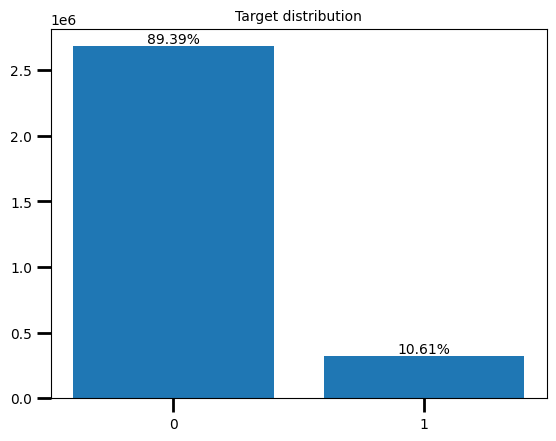

In [5]:
hist = users_feed_combined.groupby('target')['target'].count()


plt.bar(hist.index,hist.values)
plt.title('Target distribution')
plt.xticks(hist.index)

# Add labels to each bar
for i, value in enumerate(hist):
    plt.text(x=i, y=value, s=f"{round((value/hist.sum())*100,2)}%", ha='center', va='bottom')

In [37]:
#Сравнить количество пользователей попавших в выборку с общим количеством пользователей на платформе
users_in_sample=users_feed_combined['user_id'].nunique()



print(f'Пользователей в выборке - {users_in_sample}({round((users_in_sample/users.shape[0]*100),2)}%)\nВсего пользователей на платформе = {users.shape[0]}')

Пользователей в выборке - 6392(3.92%)
Всего пользователей на платформе = 163205


В выборку feed попало 3,9% пользователей.  

## 2.2 Gender, os, country, exp_group - распределение таргета по категориальным столбцам таблицы users 

In [5]:
#%%timeit_cell


# Вспомогательная функция для подписи каждого столбика в столбчатой диаграмме
    # в соответствии с его координатами

def autolabel(series, ax, labels, start_idx):
    for idx, value in enumerate(series):
        height = value.get_height()
        ax.text(value.get_x() + value.get_width() / 2., height,  # Adjust y position as needed
                labels.iloc[idx+start_idx],
                ha='center', va='bottom', rotation=0)


# функция для построения графиков распределения таргета по признаковым группам 
    # (пример: признак-пол, группы:женщины,мужчины)

def target_dist_for_feature(feature, data=users_feed_combined):

    # Calculate total counts for each feature
    amount_subgroup = data.groupby([feature])['target'].count().reset_index(name='total_count')
    
    # Calculate counts for each combination of feature and target
    amount = data.groupby([feature, 'target'])['target'].count().reset_index(name='count')
    
    # Merge to align total counts with the counts for each combination
    amount = amount.merge(amount_subgroup, on=feature)
    
    # Calculate percentages
    amount['percentage'] = round((amount['count'] / amount['total_count']) * 100, 1)
    # Convert 'percentage' and 'count' to strings
    amount['percentage_str'] = amount['percentage'].astype(str) + "%"


    sorted_percentage=amount.sort_values(by=['target', feature])['percentage_str']
    
    
    #g = sns.catplot(x=feature, kind='count', col='target', data=data, sharey=False)
    
    g = sns.catplot(data=amount, x=feature, y='count', col='target', kind='bar', 
                    sharey=False, col_wrap=2)
    g.set_xticklabels(rotation=60)
    g.set_axis_labels("", feature)
    g.fig.suptitle(f"Target distribution by {feature}", fontsize=16, ha='center', va='baseline')
    plt.subplots_adjust(top=0.85)

    cumulative_index = 0
    for ax in g.axes.flatten():
        # Get the rectangles (bars) from the current axis
        rects = ax.patches  # This gets the bars in the current subplot
        
        # Call the autolabel function with the current axis and the percentage labels
        autolabel(rects, ax, sorted_percentage, cumulative_index)
        cumulative_index+=len(rects)


#target_dist_for_feature('exp_group')


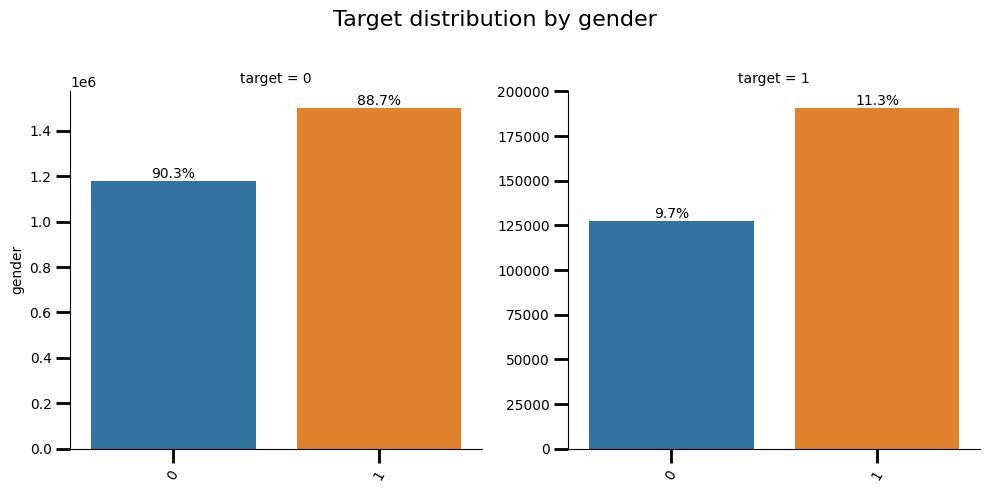

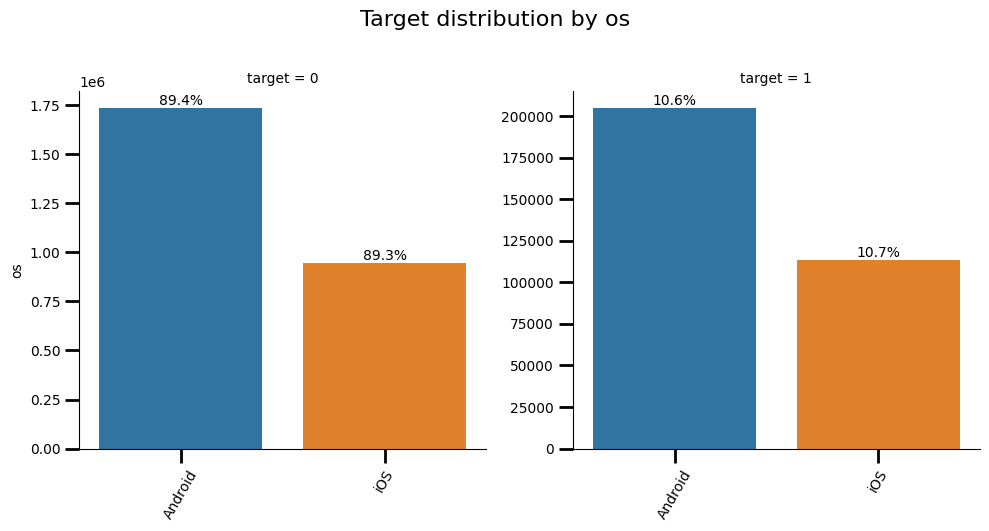

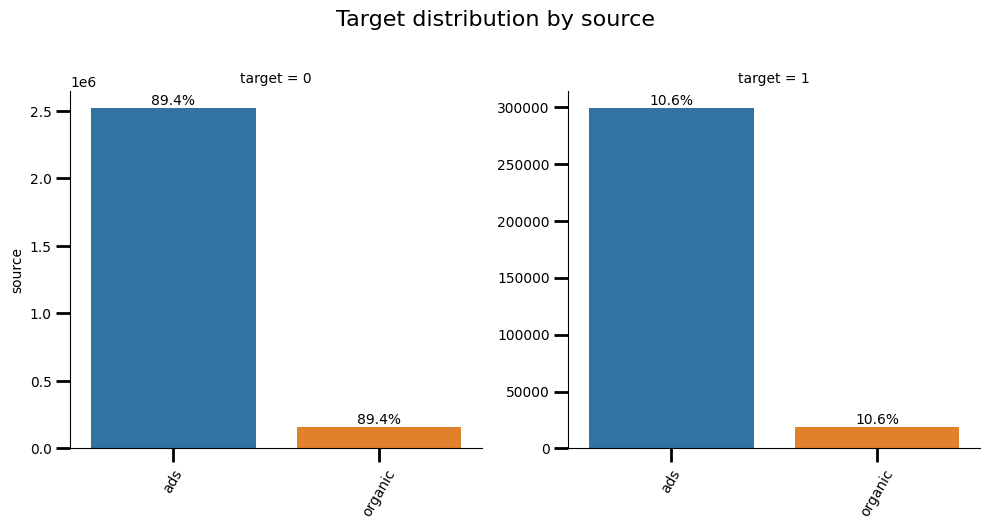

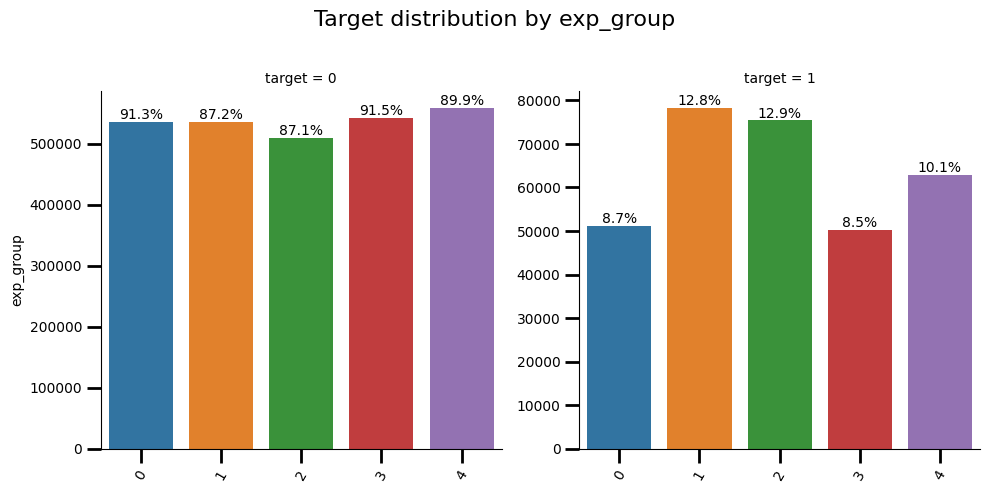

In [7]:
#user categorical features with categories<6

user_cat_features = ['gender', 'os', "source", "exp_group"]

for feature in user_cat_features:
    target_dist_for_feature(feature)

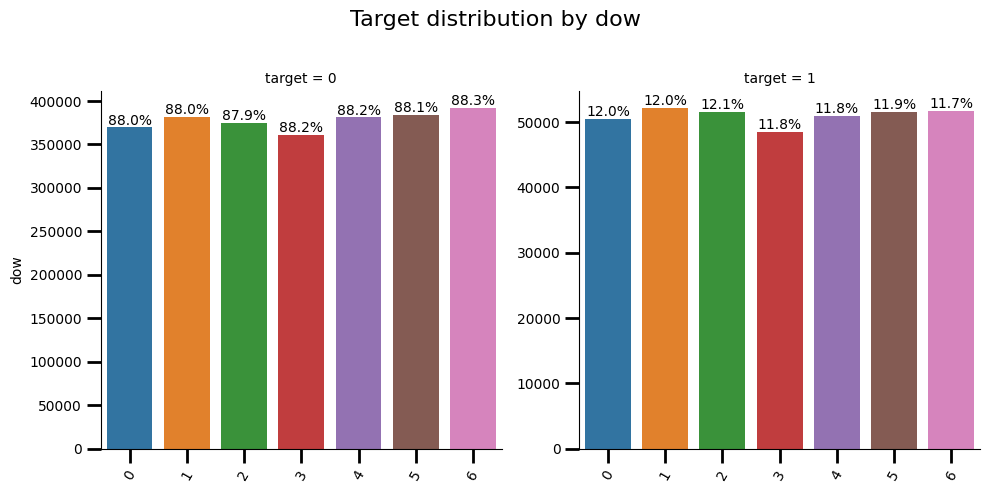

In [14]:
target_dist_for_feature('dow')

### Пояснение
На данных графиках продемонстированы соотношения лайков по группам внутри категорий <span style="color:red">gender</span>(пол), <span style="color:red">os</span>(операционная система пользователя), <span style="color:red">source</span>(откуда пришёл пользователь в приложение), <span style="color:red">exp_group</span>(произвольно выделенные группы пользователей для проведения маркетингового эксперимента) а также по дням недели - <span style="color:red">dow</span>. Столбцы графиков отстроены по абсолютным значениям, для отражения масштаба групп категорий друг относительно друга. На вершинах графиков указан процент пользователя со значением таргета 0 или 1 в конкретной группе. На основе этого можно делать вывод о том, на сколько склонна та или иная группа ставить лайки в большей или меньшей степени, чем в среднем по выборке.

### Промежуточные выводы
На платформе количественно преобладают люди пола, закодированного под "1", пользователи операционной системы "Android", привлечённые путём рекламы.

По всем рассмотренным признакам внутри групп наблюдается примерно одинаковое распределение таргета - примерно 1:9, где 1 - доля пользователей поставивших лайк. <br>
Это близко к распределению таргета по выборке в целом. Из рассмотренных признаков у двух имеется некоторое отличие в распределении таргета - gender и exp_group. Эти признаки будут использованы для построения модели

## 2.3 Age - Количество пользователей и активность - распределение таргета по признаку

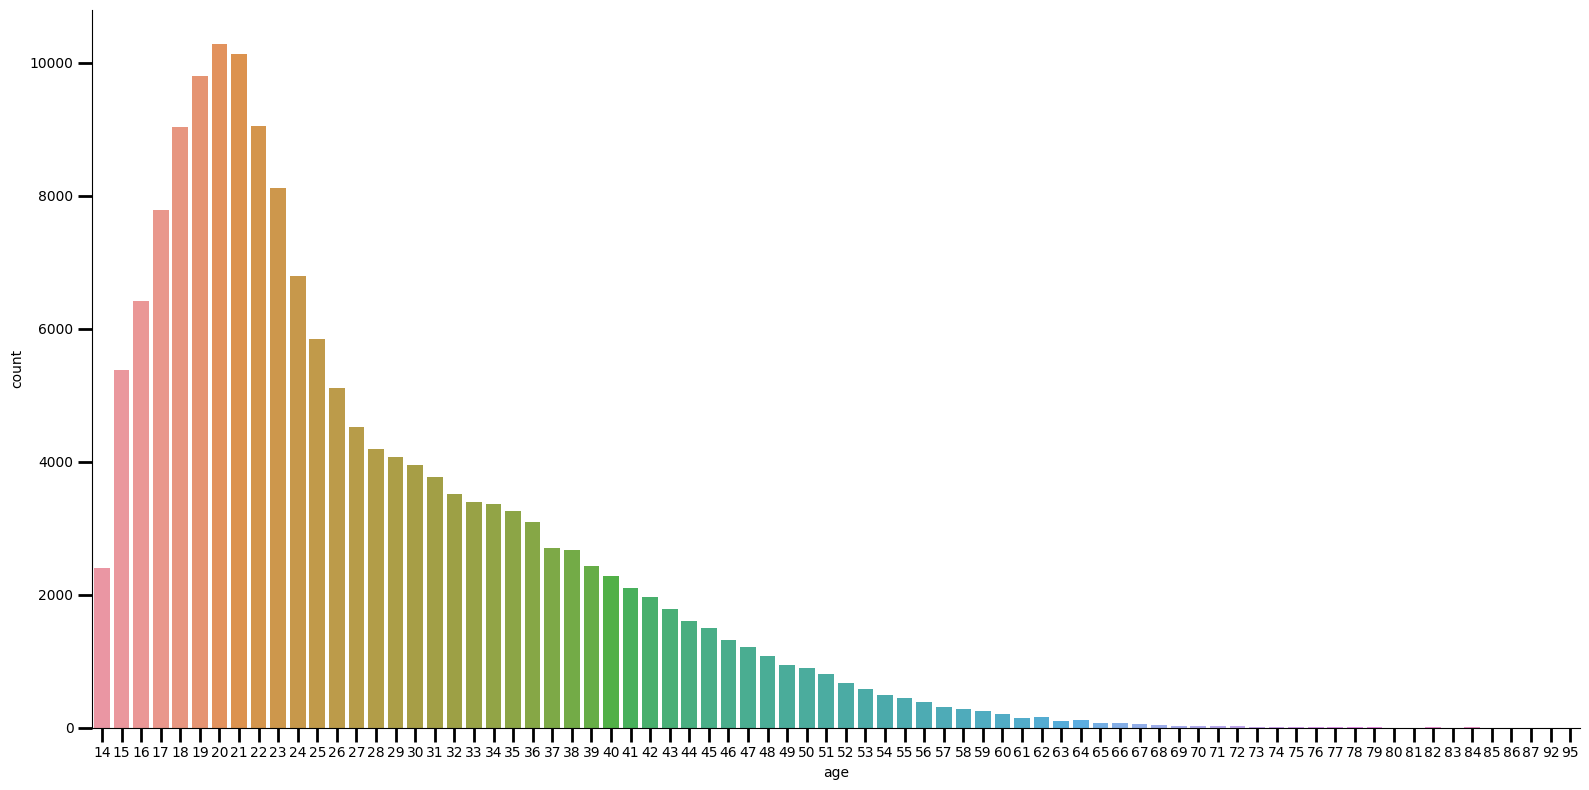

In [12]:
# распределение количества пользователей по возрасту
g= sns.catplot(data=users, x='age', kind='count',height=8, aspect=2)

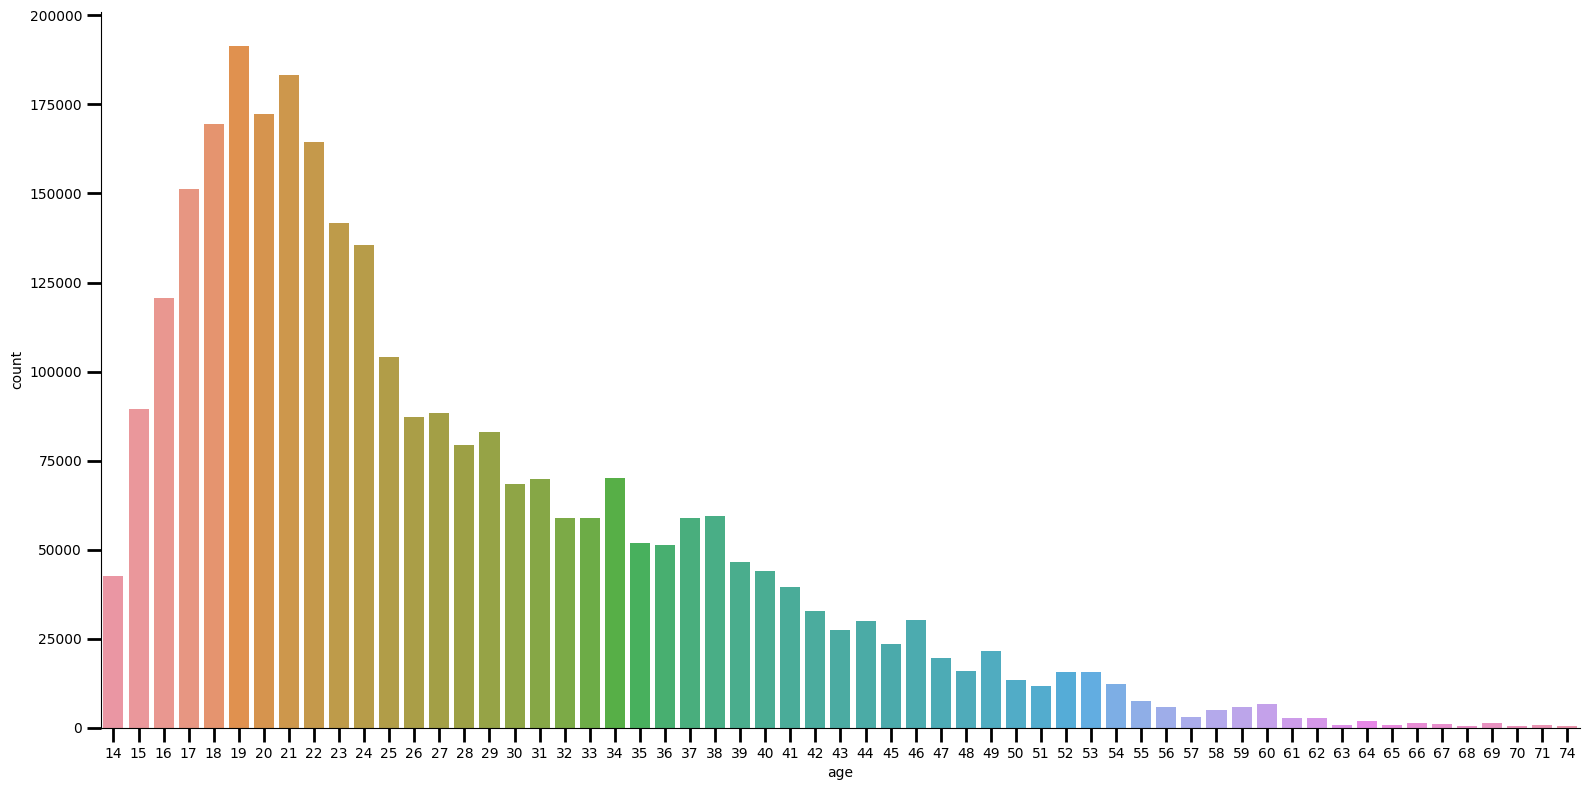

In [8]:
# распределение активности пользователей по возрасту

g = sns.catplot(data=users_feed_combined, x='age', kind='count',height=8, aspect=2)

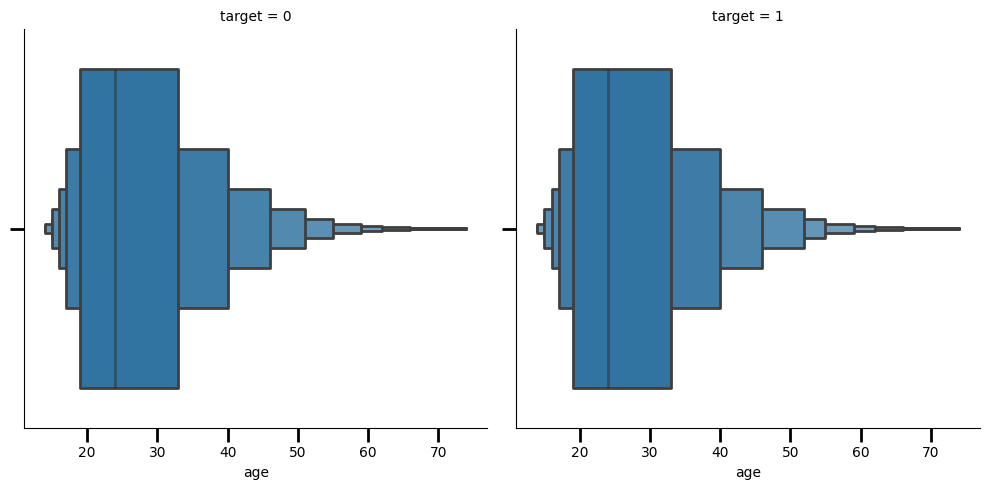

In [9]:
#распределение таргета по возрастам ~ практически не имеет значимости
g = sns.catplot(data=users_feed_combined, x='age', col='target', kind='boxen', 
                    sharey=False, col_wrap=2)

In [7]:
all_df

,user_id,gender,age,country,city,exp_group,os,source,timestamp,dow,post_id,action,target,text,topic
0,162723,1,22,Russia,Svetlogorsk,1,Android,organic,2021-10-05 14:23:10,1,3952,view,0,Read this article about training and safety of...,covid
1,162723,1,22,Russia,Svetlogorsk,1,Android,organic,2021-10-05 14:23:39,1,2530,view,1,"Syed Bokhari, 57yo HCW, Woodhull Hosp, NY, die...",covid
2,162722,0,54,Kazakhstan,Zyryanovsk,2,Android,organic,2021-10-04 12:29:28,0,6276,view,1,"Nifty little episode played mainly for laughs,...",movie
3,162722,0,54,Kazakhstan,Zyryanovsk,2,Android,organic,2021-10-04 12:30:12,0,6823,view,0,Northanger Abbey is not my favorite Jane Auste...,movie
4,162722,0,54,Kazakhstan,Zyryanovsk,2,Android,organic,2021-10-04 12:32:30,0,3495,view,1,German news Frankfurter Rundschau reporting Ge...,covid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2999995,1728,1,24,Russia,Groznyy,4,Android,ads,2021-12-28 07:09:02,1,5524,view,0,This movie is still alive and kicking today th...,movie
2999996,1728,1,24,Russia,Groznyy,4,Android,ads,2021-12-28 07:11:22,1,3337,view,0,Dangers to health of lockdown #COVID19\nhttps:...,covid
2999997,1728,1,24,Russia,Groznyy,4,Android,ads,2021-12-28 07:13:37,1,3607,view,0,#Trump has killed the #AmericanDream for milli...,covid
2999998,1728,1,24,Russia,Groznyy,4,Android,ads,2021-12-28 07:15:25,1,5675,view,0,People love the original story for its ending....,movie


Количество уникальных пользователей в каждой возрастной группе
Активность каждой возрастной группы
Склонность лайкать каждой возрастной группы

In [12]:
users['age'].min()

14

In [9]:
users.groupby((users['age'] // 10)*10)['user_id'].nunique()

age
10    40811
20    68147
30    32161
40    15797
50     5112
60     1013
70      147
80       15
90        2
Name: user_id, dtype: int64

In [6]:
feed.columns

Index(['timestamp', 'user_id', 'post_id', 'action', 'target'], dtype='object')

In [22]:
"""оценим соотношение активности пользователей по всем возрастным группам"""
feed_by_age_group = pd.read_sql("""
        WITH per_user AS (
            SELECT user_id, SUM(target) AS likes, COUNT(target) AS views
            FROM feed_data
            WHERE action <> 'like'
            GROUP BY user_id
        ),
        user_age AS (
            SELECT user_id, age
            FROM user_data
        )
        SELECT DIV(u.age, 10) AS age_group, 
                SUM(p.likes) AS total_likes,
                SUM(p.views) AS total_views,
                COUNT(u.user_id) AS unique_users
        FROM user_age u 
        JOIN per_user p ON u.user_id = p.user_id
        GROUP BY DIV(u.age, 10)
        ORDER BY age_group;""",
        conn_uri)

In [28]:
feed_by_age_group.drop('age_group_str',axis=1,inplace=True)

In [29]:
age_series = ((feed_by_age_group['age_group']).astype(np.int64)).astype(str) + '0-' + ((feed_by_age_group['age_group']).astype(np.int64)).astype(str) + '9'

feed_by_age_group['likes_per_views']= feed_by_age_group['total_likes']/feed_by_age_group['total_views']
feed_by_age_group['activity_per_user']= feed_by_age_group['total_views']/feed_by_age_group['unique_users']
feed_by_age_group['activity_per_user']= feed_by_age_group['total_views']/feed_by_age_group['unique_users']

feed_by_age_group.insert(1, "age_group_str", age_series, allow_duplicates=False)

feed_by_age_group

,age_group,age_group_str,total_likes,total_views,unique_users,ratio,likes_per_views,activity_per_user
0,1.0,10-19,2047748.0,17168585.0,40811,0.119273,0.119273,420.685232
1,2.0,20-29,3426815.0,28684317.0,68147,0.119467,0.119467,420.918265
2,3.0,30-39,1621053.0,13543692.0,32161,0.119691,0.119691,421.121607
3,4.0,40-49,790839.0,6645483.0,15797,0.119004,0.119004,420.680066
4,5.0,50-59,261092.0,2148713.0,5112,0.121511,0.121511,420.327269
5,6.0,60-69,51455.0,427645.0,1013,0.120322,0.120322,422.156960
6,7.0,70-79,6582.0,61346.0,147,0.107293,0.107293,417.319728
7,8.0,80-89,672.0,6096.0,15,0.110236,0.110236,406.400000
8,9.0,90-99,89.0,578.0,2,0.153979,0.153979,289.000000


На этой таблице прослеживается сходные соотношения лайк/просмотры, и средняя активность пользователя по возрастной группе. Только в последней группе наблюдаются выраженные изменения, что можно связать с малой представленностью группы в сформированной категории.

В данной реализации возраст будет подаваться как числовой признак, чтобы модель сама смогла найти оптимальные разбиения.

In [21]:

feed_by_age_group

,age_group,age_group_str,total_likes,total_views,ratio
0,1.0,10-19,2047748.0,17168585.0,0.119273
1,2.0,20-29,3426815.0,28684317.0,0.119467
2,3.0,30-39,1621053.0,13543692.0,0.119691
3,4.0,40-49,790839.0,6645483.0,0.119004
4,5.0,50-59,261092.0,2148713.0,0.121511
5,6.0,60-69,51455.0,427645.0,0.120322
6,7.0,70-79,6582.0,61346.0,0.107293
7,8.0,80-89,672.0,6096.0,0.110236
8,9.0,90-99,89.0,578.0,0.153979


In [12]:
%%timeit_cell
users.columns

Cell execution time: 0.0001 seconds
Current Time: 14:27:08, 16.05.2025


### Промежуточные выводы 
Наиболее многочисленная возрастная группа пользователей - люди в возрасте около 20 лет. Это отражается и в распределении активности.

Возраст также не имеет выраженного влияния на частоту лайков.

## 2.4 'city','country' - распределение пользователей а также таргета по признакам. Корелляция активности пользователей в пределах города и страны с количеством лайков.

In [50]:
# посмотреть количество пользователей по городам
users.groupby('city')['city'].count().sort_values(ascending=False)[2]/users.groupby('city')['city'].count().sort_values(ascending=False).sum()

0.012174872093379491

In [55]:
# посмотреть общее количество пользователей по странам
users.groupby('country')['country'].count().sort_values(ascending=False)

country
Russia         143035
Ukraine          8273
Belarus          3293
Kazakhstan       3172
Turkey           1606
Finland          1599
Azerbaijan       1542
Estonia           178
Latvia            175
Cyprus            170
Switzerland       162
Name: country, dtype: int64

In [37]:
#Сравнить количество пользователей попавших в выборку с общим количеством пользователей на платформе
users_in_sample=users_feed_combined['user_id'].nunique()


print(f'Пользователей в выборке - {users_in_sample}({round((users_in_sample/users.shape[0]*100),2)}%)\nВсего пользователей на платформе = {users.shape[0]}')

Пользователей в выборке - 6392(3.92%)
Всего пользователей на платформе = 163205


In [8]:
%%timeit_cell
# посмотреть отношение активности к количеству поставленных лайков по городам.
def target_by_feature_df(feature, data):
    features=[]
    if type(feature)!=list:
        features.append(feature)
    else:
        features.extend(feature)

    feature=features[-1]
    
    target_by_feature = data.groupby(features).agg(
    acts=(feature, 'count'),
    likes=('target', 'sum'),
    unique_users = ('user_id', 'nunique') # Ensure 'target' is a numeric column
    ).reset_index()

    target_by_feature['views']= target_by_feature['acts']-target_by_feature['likes']
    target_by_feature['acts_to_like_ratio, %']= round((target_by_feature['likes']/target_by_feature['acts'])*100,2)
    target_by_feature['acts_to_like_ratio, %'] = target_by_feature['acts_to_like_ratio, %']
    target_by_feature['acts_per_user']=target_by_feature['acts']/target_by_feature['unique_users']
    target_by_feature['likes_per_user']= target_by_feature['likes']/target_by_feature['unique_users']
    
    target_by_feature = target_by_feature.sort_values('acts', ascending=False)
    return target_by_feature

#Отобразить корреляцию параметров
def corr_graph(feature,data):
    df=target_by_feature_df(feature,data)
    non_numeric_columns = df.select_dtypes(exclude=['number']).columns
    df = df.drop(non_numeric_columns,axis=1)
    correlation_matrix = df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
    plt.title(f"Correlation matrix for feature '{feature}'")
    plt.show()


Cell execution time: 0.0004 seconds
Current Time: 18:03:26, 30.04.2025


### 2.4.1 Исследуется признак постов "topic"
Корелляция активности пользователей в пределах города и страны с количеством лайков.

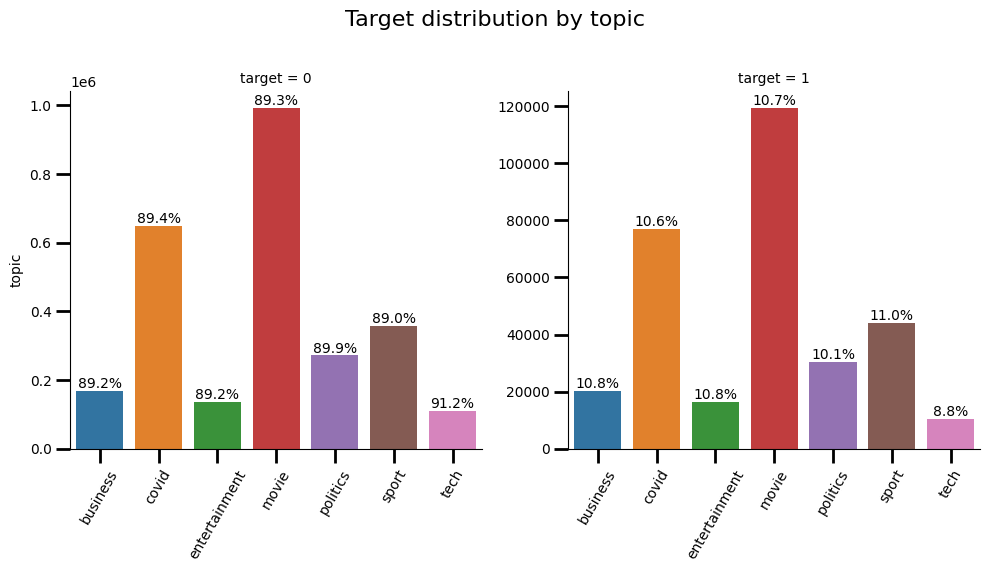

In [12]:
target_dist_for_feature('topic',all_df)

In [10]:
target_by_feature_df(['topic','exp_group'],all_df)

,topic,exp_group,acts,likes,unique_users,views,"acts_to_like_ratio, %",acts_per_user,likes_per_user
19,movie,4,230389,23741,1299,206648,10.30,177.358737,18.276366
16,movie,1,227239,29601,1276,197638,13.03,178.086991,23.198276
18,movie,3,221343,18753,1303,202590,8.47,169.871834,14.392172
15,movie,0,216364,19227,1265,197137,8.89,171.038735,15.199209
17,movie,2,216289,28087,1249,188202,12.99,173.169736,22.487590
9,covid,4,150335,15291,1299,135044,10.17,115.731332,11.771363
6,covid,1,147895,18700,1276,129195,12.64,115.905172,14.655172
8,covid,3,143724,12272,1303,131452,8.54,110.302379,9.418266
5,covid,0,141757,12536,1265,129221,8.84,112.060870,9.909881
7,covid,2,141045,18245,1249,122800,12.94,112.926341,14.607686


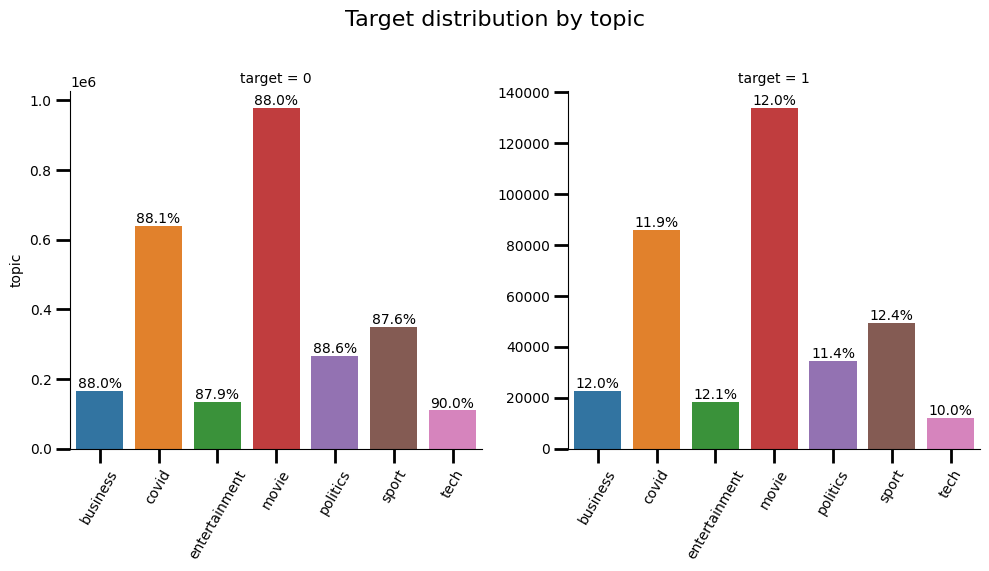

In [5]:
target_dist_for_feature('topic',all_df)

Имеется незначительное различие в распределении таргета. Признак будет опробован в модели.

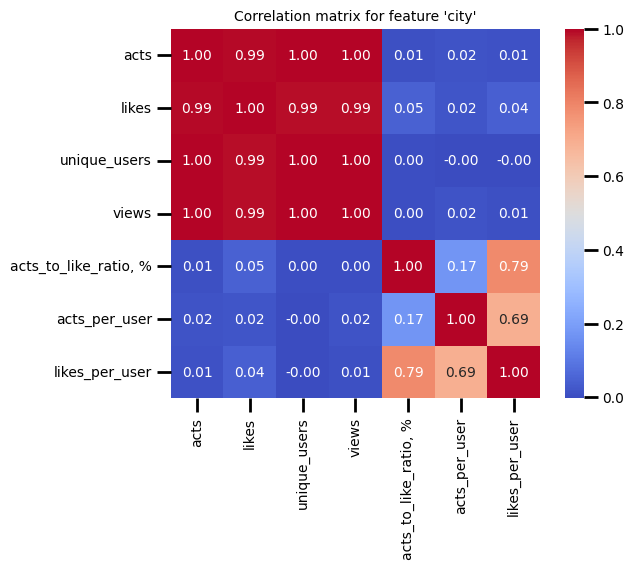

In [27]:
corr_graph('city',users_feed_combined)

In [43]:
target_by_feature_df('country',users_feed_combined)

,country,acts_per_group,likes,unique_users,"acts_to_like_ratio, %",acts_per_user,likes_per_user
7,Russia,2609866,262151,5612,10.04,465.050962,46.712580
10,Ukraine,170963,25447,340,14.88,502.832353,74.844118
1,Belarus,60903,9421,119,15.47,511.789916,79.168067
5,Kazakhstan,57360,8185,118,14.27,486.101695,69.364407
9,Turkey,32346,5474,64,16.92,505.406250,85.531250
4,Finland,28407,3490,55,12.29,516.490909,63.454545
0,Azerbaijan,26114,2377,56,9.10,466.321429,42.446429
3,Estonia,5391,607,11,11.26,490.090909,55.181818
2,Cyprus,3955,411,8,10.39,494.375000,51.375000
6,Latvia,3018,441,5,14.61,603.600000,88.200000


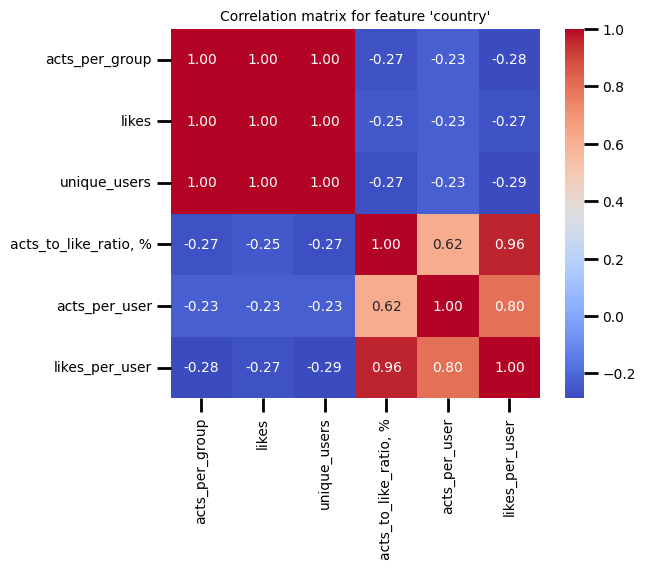

In [44]:
corr_graph('country',users_feed_combined)

### Промежуточные выводы
1) Около 87% Пользователей - из России
2) Около 13% составляют пользователи из Москвы, ~4% из Санкт-Петербурга, доля других городов в среднем - менее 1%
3) Активность пользователей на платформе пропорционально растёт с количеством пользователей по городам и странам, также имеется сильная корелляция количества просмотров и лайков.
4) Имеется различие в распределении таргета по городам и странам, но группы внутри этих категорий несбалансированы, имеются города от которых в выборку попало по одному пользователю.

## 2.5 Views - распределение доли таргета от просмотров среди всех постов в выборке

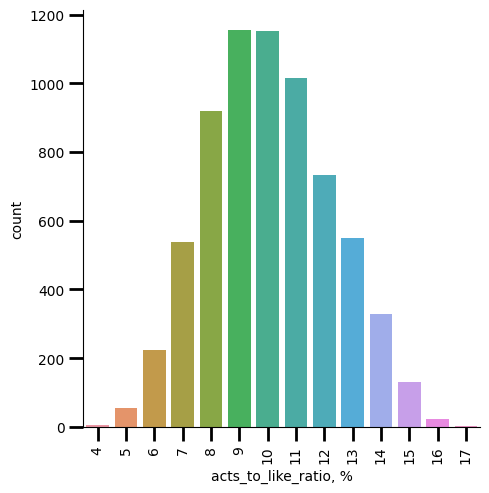

In [53]:
df=target_by_feature_df('post_id',all_df).sort_values('acts',ascending=False)
df['acts_to_like_ratio, %']=round(df['acts_to_like_ratio, %'],0).astype(int)

g = sns.catplot(data=df, x='acts_to_like_ratio, %', kind='count')
g.set_xticklabels(rotation=90)

Распределение постов по показателю доля лайков похоже на нормальное распределение, чаще всего встречаются посты с долей лайков в 10% <br>

# 3. Feature engineering и поиск оптимального набора данных

## 3.1 Подготовка класса ModelContest, чтобы наглядно сравнить качество catboost моделей на разных наборах признаков. Класс будет проводить кроссвалидацию и записывать результаты в датафрейм

Чтобы понять ценность признаков пользователей проведём обучение на этих признаках моделью catboost с неоптимизированными параметрами. В качестве информации о посте будет использоваться признак "topic".

В целях быстрого и наглядного сравнения качества моделей, обучение будет проводится на усечённой выборке - истории только первых 300 000 взаимодействий (10% от исходного набора feed). Но сначала проверим, что в усечённой выборке сохраняется распределение таргета.

In [7]:
# Сделаем усечённый вариант all_df
all_df_reduced = all_df[:300000]

"""проверяем сходство распределения таргета в первых 10% записей, 
для сохранения соотношения классов из исходной выборки"""

(all_df.groupby('target')['timestamp'].count()/all_df.shape[0])*100

target
0    88.015167
1    11.984833
Name: timestamp, dtype: float64

In [6]:
(all_df_reduced.groupby('target')['timestamp'].count()/all_df_reduced.shape[0])*100

target
0    88.069
1    11.931
Name: timestamp, dtype: float64

Соотношение таргета осталось примерно тем же, сходство до десятых процентов.


Перед обучением модели на catboost, будет проведена оценка нижнего порога точности. Будет использована метрика для сильного дисбаланса классов - f1 score, в качестве дополнительной метрики будет использован roc_auc.<br>

Для проведения оценки качества моделей на основе разных комбинаций признаков сделан класс ModelContest, который будет собирать метрики конкретного набора признаков в DataFrame, и по запросу сможет передать этот DataFrame другому экземпляру класса, чтобы можно было сравнить результаты. 

### model contest class

In [40]:
from catboost import CatBoostClassifier
import torch


class ModelContest:
    """
    A class for evaluating machine learning models with cross-validation,
    tracking metrics, and analyzing feature importances.
    
    Attributes:
        results (pd.DataFrame): DataFrame with evaluation results
        trained_models (List): List of trained models from cross-validation
        feature_importances (pd.DataFrame): DataFrame with feature importance analysis
    """
    
    def __init__(self, 
                 X:pd.DataFrame, #data
                 y:pd.Series,

                 model:Any, # model and its params
                 fit_params: Optional[Dict|None] = None,

                 checkpoint_df:Optional[pd.DataFrame|None] = None, # for results dataframe
                 model_description: str = "",

                 cv: int = 3, # for CV 
                 ):
        
        self.X = X #data
        self.y = y

        self.model = model # for model
        self.fit_params = fit_params

        self.checkpoint_df = checkpoint_df # for results df
        self.model_description = model_description

        self.cv = cv # for cv

        self.feature_names=X.columns # input based

        #initiate results_df if there is None
        if self.checkpoint_df is None:
            self.results_df = pd.DataFrame(columns=[
                'model_name',
                'model_description',
                'train_f1',
                'test_f1',
                'test_f1 variance x100',
                'train_roc_auc',
                'test_roc_auc',
                'time_spent'
            ])
        else:
            self.results_df = self.checkpoint_df
    
    
    def evaluate(self) -> None:
        """
        Evaluate model using cross-validation and store results.
        
        Args:
            X: Features DataFrame
            y: Target Series
            model: Model object with fit/predict methods
            fit_params: Additional parameters for model.fit()
            model_description: Description of the model
            cv: Number of cross-validation folds
            metrics: List of metrics to calculate
        """
        start_time = time.time()
        cv_results = {}
        self.trained_models = []
        
        

# Кросс-валидация f1, возвращает модель, 
# чтобы можно было посмотреть .get_model_features 
        cv_f1_score = cross_validate(self.model,
                                     self.X,
                                     self.y,
                                     cv=self.cv,
                                     scoring='f1',
                                     return_train_score = True,
                                     return_estimator = True,
                                    )

# Сохраняет модели полученные от cv_f1_score в переменную
        self.cv_f1_score_models = cv_f1_score['estimator']
        
# Кросс-валидация roc_auc с проверкой необходимых методов у модели
        if hasattr(self.model,"predict_proba") or hasattr(self.model,"decision_function"):
            cv_roc_auc_score = cross_validate(self.model,
                                              self.X,
                                              self.y,
                                              cv=self.cv,
                                              scoring='roc_auc',
                                              return_train_score=True)
            
            cv_roc_auc_train = round(cv_roc_auc_score['train_score'].mean(),3)
            cv_roc_auc_test = round(cv_roc_auc_score['test_score'].mean(),3)
        else:
            cv_roc_auc_train,cv_roc_auc_test  = (np.nan,np.nan)

        self.test_f1 = cv_f1_score['test_score']
        
        metrics = {
        'model_name': str(type(self.model).__name__),
        'model_description': self.model_description,
        'train_f1': round(cv_f1_score['train_score'].mean(), 3),
        'test_f1': round(cv_f1_score['test_score'].mean(), 3),
        'test_f1 variance x100': round(np.var(self.test_f1*100),4),
        'train_roc_auc': cv_roc_auc_train,
        'test_roc_auc': cv_roc_auc_test,
        'time_spent': f"{time.time() - start_time:.2f} seconds"
        }


        self.results_df = pd.concat([self.results_df, pd.DataFrame([metrics])], ignore_index=True)
        
        return self.results_df

    def get_results_df(self):
        return self.results_df

    def analyze_feature_importance(self) -> None:
        
        avg_importances = np.round(
                np.mean(
                [model.get_feature_importance() for model in self.cv_f1_score_models],
                axis=0),3
                )

        stds = np.round(
                        np.var(
                        [model.get_feature_importance() for model in self.cv_f1_score_models],
                        axis=0,ddof=1),2
                        )
        
        self.feature_importance_df = pd.DataFrame({
            'Feature': self.cv_f1_score_models[0].feature_names_,
            'Average importance': avg_importances,
            'Variance' : stds,
        })

        self.feature_importance_df.sort_values('Average importance', ascending=False,axis=0, inplace=True)
        
        return self.feature_importance_df

    def get_feature_importance(self):
        return self.feature_importance_df

    
    def save_results_df(self):
        self.results_df.to_csv('results.csv', sep=";", index=False)





# функция для создание неоптимизированная модель для ориентировочной 
# оценки метрик комбинации признаков

def make_catboost_model(cat_feats):
    use_gpu = torch.cuda.is_available()
    model = CatBoostClassifier(cat_features=cat_feats,
                               auto_class_weights='Balanced', # для учёта моделью дисбаланса классов
                               iterations=100,       # количество деревьев
                               learning_rate=0.1,    # скорость обучения
                               task_type="GPU" if use_gpu else "CPU", # использование GPU (убедитесь, что CUDA установлена)      # какие GPU использовать (можно указать несколько)
                               verbose=0)
    return(model)

### Model 0. Dummy classifier - baseline

In [41]:
from sklearn.dummy import DummyClassifier

leak_fs=['target','user_id', 'post_id', 'timestamp','text','action']

X=all_df_reduced.drop(leak_fs, axis=1)
y=all_df_reduced['target']

model = DummyClassifier(strategy="most_frequent")

model_test0 = ModelContest(X=X,
                           y=y,
                           model=model,
                           model_description="baseline")

model_test0.evaluate()

,model_name,model_description,train_f1,test_f1,test_f1 variance x100,train_roc_auc,test_roc_auc,time_spent
0,DummyClassifier,baseline,0.0,0.0,0.0,0.5,0.5,0.70 seconds


### Model 1. Catboost - all user features

In [ ]:
# список признаков на удаление из тренировочного набора
leak_fs=['target','user_id', 'post_id', 'timestamp','text','action']
disbalanced_fs=['city','country']
low_importance_fs = ['os','dow','source']

# список категориальных признаков, для подачи на модель catboost
X=all_df_reduced.drop(leak_fs, axis=1)
y=all_df_reduced['target']

# список категориальных признаков, для подачи на модель catboost
cat_feats = ['gender', 'country','city','exp_group','os','source','dow', 'topic']
cat_feats = [item for item in cat_feats if item in list(X.columns)]

#инициализация модели catboost при помощи ранее написанной функции
catboost_model = make_catboost_model(cat_feats)

# создание экземпляра класса, из которого далее можно получать сравнительную таблицу 
# эффективности моделей а также подавать эту же таблицу 
# другим экземплярам того же класса, для продолжения её заполнения

model_test1 = ModelContest(X=X,
                           y=y,
                           model=catboost_model,
                           model_description="all user features",
                           checkpoint_df = model_test0.get_results_df()
                           )

model_test1.evaluate()

,model_name,model_description,train_f1,test_f1,test_f1 variance x100,train_roc_auc,test_roc_auc,time_spent
0,DummyClassifier,baseline,0.000,0.000,0.000,0.500,0.500,0.70 seconds
1,CatBoostClassifier,all user features,0.273,0.247,0.665,0.661,0.605,30.87 seconds


In [43]:
model_test1.analyze_feature_importance()

,Feature,Average importance,Variance
8,topic,31.521,11.06
3,city,30.283,1.71
1,age,21.595,2.16
4,exp_group,9.969,2.21
2,country,3.070,0.85
0,gender,2.453,0.63
5,os,0.844,0.13
7,dow,0.265,0.01
6,source,0.000,0.00


В данной реализации рекомендательной системы далее будут исключены признаки с наименьшей значимостью - "os","dow","source".

### Model 2. Catboost - removed low importance feats

In [44]:
leak_fs=['target','user_id', 'post_id', 'timestamp','text','action']
disbalanced_fs=['city','country']
low_importance_fs = ['os','dow','source']

X=all_df_reduced.drop(leak_fs + low_importance_fs, axis=1)
y=all_df_reduced['target']

cat_feats = ['gender', 'country','city','exp_group','os','source','dow', 'topic']
cat_feats = [item for item in cat_feats if item in X.columns]


catboost_model = make_catboost_model(cat_feats)

model_test2 = ModelContest(X=X,
                           y=y,
                           model=catboost_model,
                           model_description="removed low importance",
                           checkpoint_df=model_test1.get_results_df()
                           )

model_test2.evaluate()

,model_name,model_description,train_f1,test_f1,test_f1 variance x100,train_roc_auc,test_roc_auc,time_spent
0,DummyClassifier,baseline,0.000,0.000,0.0000,0.500,0.500,0.70 seconds
1,CatBoostClassifier,all user features,0.273,0.247,0.6650,0.661,0.605,30.87 seconds
2,CatBoostClassifier,removed low importance,0.273,0.245,0.5369,0.661,0.603,26.59 seconds


# Признак 'text' из таблицы posts - feature engineering

## 3.2 tf-ifd + PCA + KMeans cluster - Преобразование признака 'text' из таблицы posts

In [55]:
%%timeit_cell
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Общая схема: tf-idf->PCA->knn

# Проводится работа с датафреймом posts 
# Инициализируется экземпляр трансформера tfidf
tfidf = TfidfVectorizer(stop_words='english')
#создаётся numpy массив с результатом обработки столбца 'text' из исходного датафрейма post, 
tfidf_data = tfidf.fit_transform(posts['text']).toarray()
#Преобразуется в датафрейм с post_id в качестве индекса и названиями признаков в качестве заголовков столбцов
tfidf_data = pd.DataFrame(tfidf_data, index=posts.post_id, columns=tfidf.get_feature_names_out())

# Значения центрируются за счёт вычитания среднего по датафрейму
tfidf_data = tfidf_data - tfidf_data.mean()



Cell execution time: 10.0372 seconds
Current Time: 15:08:09, 03.07.2025


In [12]:
#посмотрим размерность
tfidf_data.shape

(7023, 51534)

In [56]:
#Размерность признаков понижается до 20 за счёт экземпляра PCA класса
pca = PCA(n_components=20)
pca_decomp = pca.fit_transform(tfidf_data)

#образуется промежуточный датафрейм для хранения результатов tfidf анализа с уменьшенной за счёт pca размерностью
pca_decomp_df = pd.DataFrame(pca_decomp)
pca_decomp_df = pca_decomp_df.rename(columns={col: f'pca-{col}' for col in pca_decomp_df.columns})

#Результаты анализа уменьшенной размерности, в свою очередь, подаются на knn кластеризацию
#Создание экземпляра класса одновременно с обучением
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(pca_decomp)

In [32]:
users_feed_combined[:300000]

,user_id,gender,age,country,city,exp_group,os,source,timestamp,dow,post_id,action,target
0,162723,1,22,Russia,Svetlogorsk,1,Android,organic,2021-10-05 14:23:10,1,3952,view,0
1,162723,1,22,Russia,Svetlogorsk,1,Android,organic,2021-10-05 14:23:39,1,2530,view,1
2,162722,0,54,Kazakhstan,Zyryanovsk,2,Android,organic,2021-10-04 12:29:28,0,6276,view,1
3,162722,0,54,Kazakhstan,Zyryanovsk,2,Android,organic,2021-10-04 12:30:12,0,6823,view,0
4,162722,0,54,Kazakhstan,Zyryanovsk,2,Android,organic,2021-10-04 12:32:30,0,3495,view,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:36:34,2,5269,view,0
299996,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:38:35,2,6631,view,0
299997,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:40:59,2,3480,view,0
299998,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:41:48,2,3027,view,0


In [57]:
%%timeit_cell
from sklearn.preprocessing import StandardScaler

posts_tf_idf = posts.copy(deep=True)

#Добавление признака "text_cluster" к posts 
posts_tf_idf['text_cluster'] = kmeans.labels_

#Создание датафрейма с вычислением расстояний до каждого кластера
dists_columns_names = [f"DistanceTo{ith}thCluster" for ith in range(1, n_clusters + 1)]

dists_df = pd.DataFrame(
    data=kmeans.transform(pca_decomp),
    columns=dists_columns_names
)

"""Для наглядной оценки ценности признака - "расстояния до кластера"
попробую ужать его методом PCA, но перед этим проведу мастшабирование
значений""" 

scaler = StandardScaler()
dists_df_scaled = scaler.fit_transform(dists_df)
pca = PCA(n_components=2)
pca_results = pca.fit_transform(dists_df_scaled)


posts_tf_idf['pca_dists_1'] = pca_results[:, 0]
posts_tf_idf['pca_dists_2'] = pca_results[:, 1]


# unite post_text_df, pca, knn_cluster

posts_tf_idf = pd.concat((posts_tf_idf,dists_df,pca_decomp_df), axis=1)

all_df_tf_idf = users_feed_combined[:300000].merge(posts_tf_idf,left_on="post_id", right_on="post_id")

Cell execution time: 0.0769 seconds
Current Time: 15:09:19, 03.07.2025


In [38]:
all_df_tf_idf

,user_id,gender,age,country,city,exp_group,os,source,timestamp,dow,...,pca-10,pca-11,pca-12,pca-13,pca-14,pca-15,pca-16,pca-17,pca-18,pca-19
0,162723,1,22,Russia,Svetlogorsk,1,Android,organic,2021-10-05 14:23:10,1,...,0.026316,0.006630,0.008195,0.012985,0.003146,0.018030,0.003108,-0.022872,0.006394,0.012341
1,162723,1,22,Russia,Svetlogorsk,1,Android,organic,2021-10-05 14:23:39,1,...,0.004621,-0.013022,-0.001230,0.001963,-0.008382,0.001274,-0.003529,-0.009192,0.002223,-0.002192
2,162722,0,54,Kazakhstan,Zyryanovsk,2,Android,organic,2021-10-04 12:29:28,0,...,-0.045158,-0.025492,-0.019273,-0.014826,0.011090,-0.012531,0.009935,0.003415,0.011443,-0.008234
3,162722,0,54,Kazakhstan,Zyryanovsk,2,Android,organic,2021-10-04 12:30:12,0,...,-0.018739,-0.077900,-0.001202,0.011437,0.012969,0.018364,0.020915,-0.008189,0.030071,-0.011869
4,162722,0,54,Kazakhstan,Zyryanovsk,2,Android,organic,2021-10-04 12:32:30,0,...,0.006809,-0.000114,-0.004427,0.009471,0.000252,0.013953,0.006416,-0.014530,0.006183,0.001312
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:36:34,2,...,-0.048684,0.060632,0.014715,-0.040949,-0.006769,-0.005369,-0.043826,-0.015793,0.008033,0.028164
299996,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:38:35,2,...,-0.024490,-0.036481,-0.017117,-0.002557,-0.001854,-0.004334,0.011636,0.008929,0.022182,-0.008385
299997,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:40:59,2,...,-0.002370,-0.012649,-0.035921,-0.026273,0.017653,-0.000422,-0.027276,0.006518,-0.013391,0.023759
299998,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:41:48,2,...,0.006263,-0.017674,0.002489,-0.010018,-0.027957,0.010107,-0.041235,0.012356,-0.000146,0.002032


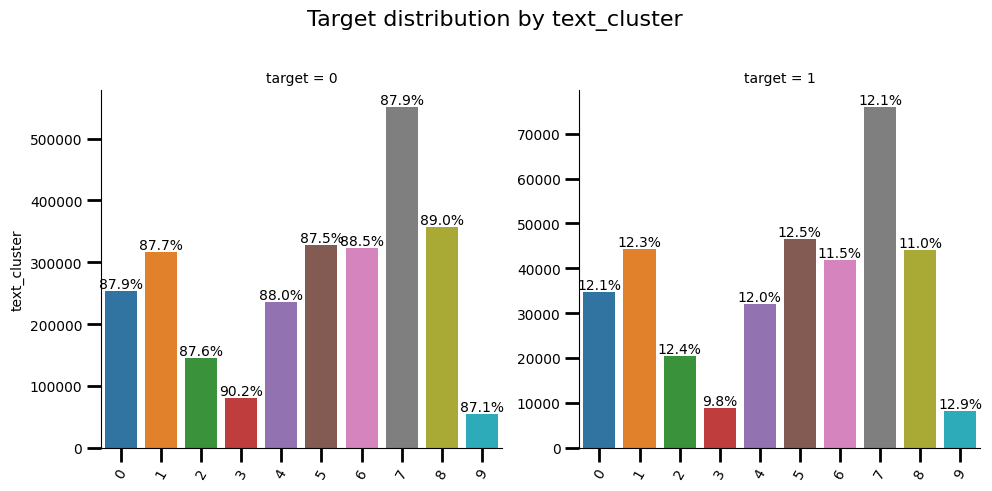

In [54]:
target_dist_for_feature("text_cluster",data=all_df)

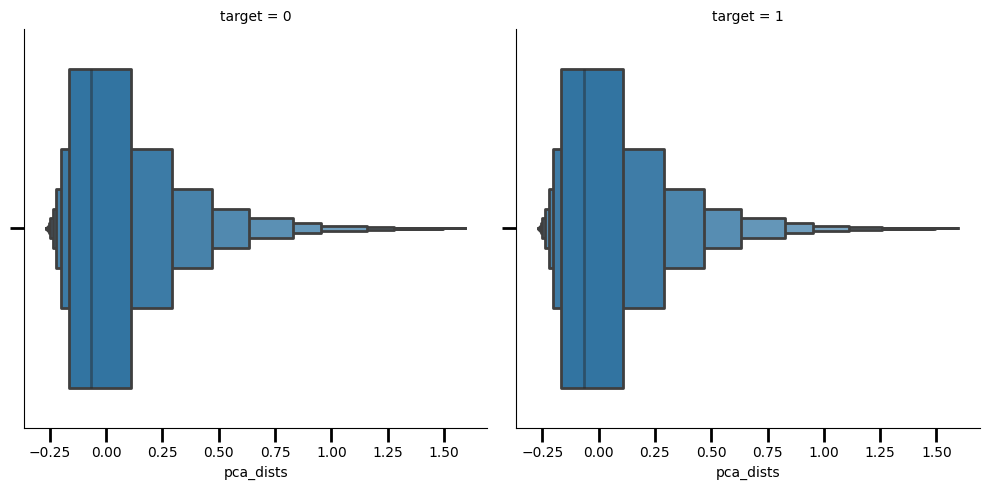

In [55]:
g = sns.catplot(data=all_df, x='pca_dists', col='target', kind='boxen', 
                    sharey=False, col_wrap=2)

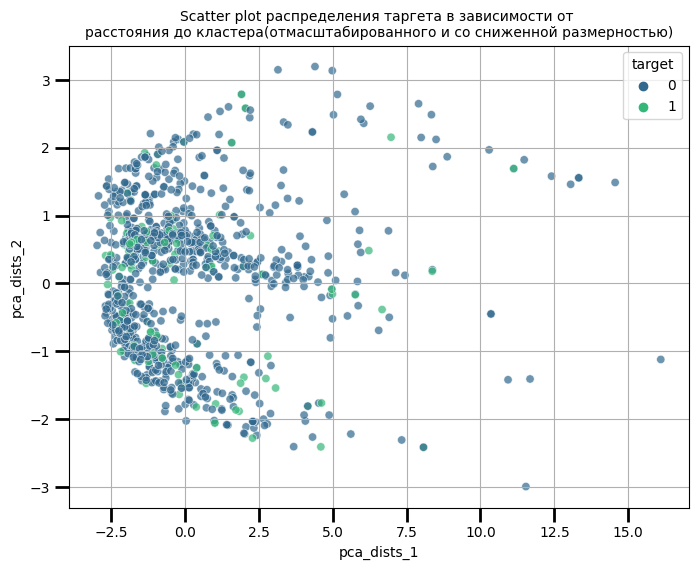

In [58]:
# Строим scatter plot с hue=Target
plt.figure(figsize=(8, 6))
sns.scatterplot(data=all_df.sample(n=1000, random_state=42), x='pca_dists_1', y="pca_dists_2", hue='target', palette='viridis', alpha=0.7)
plt.title('Scatter plot распределения таргета в зависимости от \n\
расстояния до кластера(отмасштабированного и со сниженной размерностью)')
plt.grid(True)
plt.show()

In [56]:
target_by_feature_df(['text_cluster','exp_group'],all_df)

,text_cluster,exp_group,acts,likes,unique_users,views,"acts_to_like_ratio, %",acts_per_user,likes_per_user
38,7,3,127349,12398,1450,114951,9.74,87.826897,8.550345
37,7,2,126942,18867,1467,108075,14.86,86.531697,12.860941
39,7,4,126460,14244,1409,112216,11.26,89.751597,10.109297
36,7,1,123793,18574,1406,105219,15.00,88.046230,13.210526
35,7,0,122689,11898,1400,110791,9.70,87.635000,8.498571
42,8,2,83111,11399,1467,71712,13.72,56.653715,7.770279
43,8,3,82087,7013,1450,75074,8.54,56.611724,4.836552
44,8,4,79874,8111,1409,71763,10.15,56.688432,5.756565
41,8,1,78553,10923,1406,67630,13.91,55.869844,7.768848
40,8,0,78138,6636,1400,71502,8.49,55.812857,4.740000


Можно увидеть небольшое отличие в распределении таргета по кластерам.

В тоже время, признак "расстояние до кластеров" (для наглядности уменьшеный в размерности) не дает заметной разницы в распределении по таргетам.  Scatterplot с распределениями таргета в зависимости от расстояний до кластера, (отмасштабированных и с уменьшенной размерностью методом pca), так же не показывает чёткого различия.  

Здесь будет произведена попытка скомбинировать "хорошие" признаки пользователей с признаками постов 

### Model 3. (user features - low importance) and tf_idf based features

In [ ]:
# список признаков на удаление из тренировочного набора
leak_fs=['target','user_id', 'post_id', 'timestamp','text','action']
disbalanced_fs=['city','country']
low_importance_fs = ['os','dow','source']

X=all_df_tf_idf.drop(leak_fs + low_importance_fs, axis=1)
y=all_df_tf_idf['target']

# список категориальных признаков, для подачи на модель catboost
cat_feats = ['text_cluster', 'gender', 'country','city','exp_group','os','source','dow', 'topic']
cat_feats = [item for item in cat_feats if item in X.columns]

#инициализация модели catboost при помощи ранее написанной функции
catboost_model = make_catboost_model(cat_feats)

# создание экземпляра класса, из которого далее можно получать сравнительную таблицу 
# эффективности моделей а также подавать таблицу 
# другим экземплярам того же класса, для продолжения таблицы

model_test3 = ModelContest(X=X,
                           y=y,
                           model=catboost_model,
                           model_description="minus low importance and added tf_idf based feats",
                           checkpoint_df=model_test2.get_results_df()
                           )

model_test3.evaluate()

,model_name,model_description,train_f1,test_f1,test_f1 variance x100,train_roc_auc,test_roc_auc,time_spent
0,DummyClassifier,baseline,0.000,0.000,0.0000,0.500,0.500,0.70 seconds
1,CatBoostClassifier,all user features,0.273,0.247,0.6650,0.661,0.605,30.87 seconds
2,CatBoostClassifier,removed low importance,0.273,0.245,0.5369,0.661,0.603,26.59 seconds
3,CatBoostClassifier,minus low importance and added tf_idf based feats,0.286,0.253,0.4835,0.683,0.617,68.39 seconds


In [50]:
model_test3.save_results_df()

In [46]:
model_test3.analyze_feature_importance()

,Feature,Average importance,Variance
1,age,22.980,0.00
3,city,21.872,3.87
23,pca-4,6.823,5.46
4,exp_group,6.714,1.81
5,topic,5.930,8.70
20,pca-1,3.447,3.56
24,pca-5,2.357,0.08
25,pca-6,2.323,0.01
30,pca-11,2.229,0.00
2,country,2.171,0.54


## 3.3 distilbert embedding преобразование признака 'text' из таблицы post

In [ ]:
## очередная попыька

In [5]:
import torch
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, DistilBertModel, DataCollatorWithPadding
import pandas as pd
import numpy as np
from tqdm import tqdm


# Устройство (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Загружаем модель и токенизатор
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-cased")
model = DistilBertModel.from_pretrained("distilbert-base-cased").to(device)
model.eval()  # Режим инференса

# Функция для получения эмбеддингов
@torch.inference_mode()
def get_bert_embeddings(
                        texts: list[str],
                        model: DistilBertModel,
                        tokenizer: AutoTokenizer,
                        batch_size: int = 32,
                        ) -> np.ndarray:
    """Получает BERT-эмбеддинги для списка текстов батчами."""
    
    # Токенизируем все тексты сразу
    tokenized_texts = tokenizer(texts, padding=True, truncation=True, return_tensors="pt", return_attention_mask=True)
    
    # Создаём Dataset из токенизированных текстов
    class TextDataset(torch.utils.data.Dataset):
        def __init__(self, encodings):
            self.encodings = encodings
            
        def __getitem__(self, idx):
            return {key: val[idx] for key, val in self.encodings.items()}
            
        def __len__(self):
            return len(self.encodings.input_ids)
    
    dataset = TextDataset(tokenized_texts)
    
    # Создаём DataLoader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,        # Сохраняем порядок текстов
        num_workers=4,       # Параллельная загрузка (ускоряет обработку)
    )
    
    embeddings = []
    
    # Обрабатываем батчи с прогресс-баром
    for batch in tqdm(dataloader, desc="Получение эмбеддингов"):
        # Перемещаем данные на GPU (если доступно)
        batch = {k: v.to(device) for k, v in batch.items()}
        
        # Получаем эмбеддинги
        outputs = model(**batch)
        
        # Берём эмбеддинг [CLS]-токена (для всего предложения)
        cls_embedding = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_embedding)
    
    return np.vstack(embeddings)  # Объединяем все батчи в одну матрицу


# Загружаем данные (пример)  
texts = posts["text"].tolist()

# Получаем эмбеддинги
embeddings = get_bert_embeddings(texts, model, tokenizer)

# Результат: матрица [число текстов × 768]
print(f"Размерность эмбеддингов: {embeddings.shape}")

Получение эмбеддингов:   0%|          | 0/220 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKE

Размерность эмбеддингов: (7023, 768)


In [ ]:
#cоздаём датафрейм из эмбеддингов и подсоединяем post_id
embs_df = pd.DataFrame(embeddings, columns=[f'emb_{i+1}' for i in range(embeddings.shape[1])])
embs_df.insert(0, 'post_id', posts['post_id'])

Создаём датафрейм, на основе данных об активности пользователей,
оставим там только таргет, post_id, и эмбеддинги
Но сначала сократим количество строк из датафрейма об активности пользователей
Датафрейм размером ~3m*768 может перегрузить память. 
<br> <br> Проверим сходство
распределения таргета в первых 10% записей с общим количеством данных

In [ ]:
feed.groupby('target')['timestamp'].count()/feed.shape[0]

target
0    0.880152
1    0.119848
Name: timestamp, dtype: float64

Для увеличения скорости и экономии ресурсов модели будет опробован метод сжатия информации из полученных bert эмбеддингов путём pca и k-means кластеризации.

In [74]:
from sklearn.preprocessing import StandardScaler

# Assuming `embeddings` is a NumPy array of shape (n_samples, n_features)
scaler = StandardScaler()

scaled_embeddings = scaler.fit_transform(embs_df.iloc[:,1:])


# PCA initialising
pca = PCA(n_components=50)
pca_embeddings = pca.fit_transform(scaled_embeddings)

# clustering
embs_clusters = KMeans(n_clusters=10).fit_predict(pca_embeddings)

# first five pca columns go to embs pca 
embs_pca = pca_embeddings[:, :5]  # First 5 components

# combining dataframe for model
embs_clusters = pd.DataFrame(embs_clusters, columns=['embs_clusters'])
embs_pca = pd.DataFrame(embs_pca, columns=[f"pca_{i}" for i in range(len(embs_pca[0]))])

posts_bert_reduced = pd.concat([posts['post_id'],
                               embs_clusters,embs_pca],
                               axis=1)

posts_bert_reduced

,post_id,embs_clusters,pca_0,pca_1,pca_2,pca_3,pca_4
0,7319,8,-9.279914,-4.139495,-1.889438,4.396156,0.226890
1,7318,4,-15.859632,-4.387825,0.628919,1.176736,3.080240
2,7317,9,-5.512975,-8.323260,3.059692,-2.025389,-2.520628
3,7316,9,-7.930210,-7.138633,-0.400262,-4.656809,-0.224738
4,7315,9,-10.466970,-4.978283,-0.611080,-0.073816,0.411999
...,...,...,...,...,...,...,...
7018,5,3,4.501861,7.848860,-8.432307,7.406117,-2.802935
7019,4,3,9.512004,9.061256,-16.848836,6.167778,9.188528
7020,3,3,8.408785,12.509196,-14.306073,9.165525,-0.288764
7021,2,3,8.653503,15.379483,-9.452297,0.467995,1.206903


In [79]:
### combining all_df_reduced with bert_reduced
all_df_and_bert_reduced = pd.merge(all_df_reduced, posts_bert_reduced, on='post_id', how='left')
all_df_and_bert_reduced

,user_id,gender,age,country,city,exp_group,os,source,timestamp,dow,...,action,target,text,topic,embs_clusters,pca_0,pca_1,pca_2,pca_3,pca_4
0,162723,1,22,Russia,Svetlogorsk,1,Android,organic,2021-10-05 14:23:10,1,...,view,0,Read this article about training and safety of...,covid,6,15.139550,-10.207989,-3.102052,-3.382162,3.884370
1,162723,1,22,Russia,Svetlogorsk,1,Android,organic,2021-10-05 14:23:39,1,...,view,1,"Syed Bokhari, 57yo HCW, Woodhull Hosp, NY, die...",covid,6,10.094795,-6.689368,3.457017,4.634820,4.291343
2,162722,0,54,Kazakhstan,Zyryanovsk,2,Android,organic,2021-10-04 12:29:28,0,...,view,1,"Nifty little episode played mainly for laughs,...",movie,4,-14.150468,-4.410165,4.936524,0.557197,-2.172503
3,162722,0,54,Kazakhstan,Zyryanovsk,2,Android,organic,2021-10-04 12:30:12,0,...,view,0,Northanger Abbey is not my favorite Jane Auste...,movie,4,-15.066170,-6.749951,0.276898,-4.625745,-1.673294
4,162722,0,54,Kazakhstan,Zyryanovsk,2,Android,organic,2021-10-04 12:32:30,0,...,view,1,German news Frankfurter Rundschau reporting Ge...,covid,2,15.360176,-5.519767,-2.971968,1.539232,2.124791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:36:34,2,...,view,0,This is without question one of the worst movi...,movie,9,-13.023452,-4.535600,-0.761677,-2.942659,-2.660287
299996,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:38:35,2,...,view,0,"One of the unsung gems of the 1980s, Scenes......",movie,4,-12.449260,-6.437435,-2.968962,-2.439247,3.411909
299997,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:40:59,2,...,view,0,Hey guys am in search of Nembutal pills or the...,covid,2,11.448473,-9.389787,2.241998,-0.638149,4.879437
299998,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:41:48,2,...,view,0,@hackneycouncil So your repair team told my ch...,covid,6,11.710077,-8.645109,6.298104,-3.359497,-1.021533


### Model 4. (user features - low importance) + (distillbert embeddings + PCA)

In [80]:
leak_fs=['target','user_id', 'post_id', 'timestamp','text','action']
disbalanced_fs=['city','country']
low_importance_fs = ['os','dow','source']


X=all_df_reduced.drop(leak_fs + low_importance_fs, axis=1)
y=all_df_and_bert_reduced['target']

cat_feats = ['embs_clusters', 'gender', 'country','city','exp_group','os','source','dow', 'topic']
cat_feats = [item for item in cat_feats if item in X.columns]

catboost_model = make_catboost_model(cat_feats)

model_tests5 = ModelContest(X=X,
                           y=y,
                           model=catboost_model,
                           model_description="minus low importance + scaled bert embeddings",
                           checkpoint_df=model_tests4.get_results_df()
                           )

model_tests5.evaluate()

,model_name,model_description,train_f1,test_f1,train_roc_auc,test_roc_auc,time_spent
0,CatBoostClassifier,all user features,0.273,0.247,0.661,0.605,23.24 seconds
1,CatBoostClassifier,minus low importance,0.273,0.245,0.661,0.603,20.13 seconds
2,CatBoostClassifier,minus low importance and tf_idf based feats,0.287,0.255,0.684,0.617,54.88 seconds
3,CatBoostClassifier,minus low importance and tf_idf based feats,0.278,0.249,0.670,0.610,27.35 seconds
4,CatBoostClassifier,minus low importance + scaled bert embeddings,0.273,0.245,0.661,0.603,17.92 seconds


In [83]:
model_tests5.get_results_df()

,model_name,model_description,train_f1,test_f1,train_roc_auc,test_roc_auc,time_spent
0,CatBoostClassifier,all user features,0.273,0.247,0.661,0.605,23.24 seconds
1,CatBoostClassifier,minus low importance,0.273,0.245,0.661,0.603,20.13 seconds
2,CatBoostClassifier,minus low importance and tf_idf based feats,0.287,0.255,0.684,0.617,54.88 seconds
3,CatBoostClassifier,minus low importance and tf_idf based feats,0.278,0.249,0.670,0.610,27.35 seconds
4,CatBoostClassifier,minus low importance + scaled bert embeddings,0.273,0.245,0.661,0.603,17.92 seconds


In [14]:
feed[:300000].groupby('target')['timestamp'].count()/feed[:300000].shape[0]

target
0    0.88285
1    0.11715
Name: timestamp, dtype: float64

Соотношение таргета незначительно отличается по всей выборке и в срезе, куда попали лишь первые 10% от всей выборки. Для оптимального использования памяти и вычислительных ресурсов, эмбеддинг будет объединён только с первыми 10% истории взаимодействий.

In [22]:
feed_reduced=feed[:300000]

columns_to_save = ['post_id','target']
embs_feed_df = pd.merge(feed_reduced[columns_to_save], embs_df, on='post_id', how='left')
embs_feed_df

,post_id,target,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_759,emb_760,emb_761,emb_762,emb_763,emb_764,emb_765,emb_766,emb_767,emb_768
0,192,0,0.225021,-0.151109,-0.228632,-0.245231,-0.344227,-0.032977,0.342910,-0.004017,...,0.392812,0.251731,-0.175618,0.123908,0.115783,0.206039,0.038509,-0.253873,0.052467,-0.096209
1,1271,0,0.303284,0.062454,-0.393550,-0.136780,-0.177486,-0.151303,0.429259,-0.096064,...,0.324258,0.327207,-0.105066,0.172764,-0.182798,0.237602,-0.155278,0.046349,-0.057035,0.165651
2,6094,1,0.164185,0.059175,-0.044354,-0.077194,-0.249639,-0.113866,0.334600,-0.201199,...,0.386460,0.075377,-0.384609,-0.106025,0.040733,0.090672,-0.080865,0.030067,0.303851,0.080104
3,4697,0,0.394347,-0.057621,-0.109992,-0.066483,-0.015631,-0.130813,0.299420,-0.228781,...,0.416558,0.256182,-0.170734,0.117464,0.138780,0.095777,-0.040446,-0.048855,0.112289,0.066746
4,5495,1,0.329259,-0.039581,-0.068384,-0.183696,0.071664,-0.065420,0.176600,-0.309079,...,0.409977,0.138180,-0.131102,0.279636,0.070506,0.053566,0.078319,-0.090015,0.148629,0.112141
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,2183,0,0.446468,-0.040722,-0.185779,-0.238638,-0.184572,-0.128932,0.333324,-0.090390,...,0.459015,0.177724,-0.027962,0.098765,0.099921,0.056779,-0.006798,-0.262650,0.114146,0.125011
299996,1721,0,0.533992,-0.137064,-0.203205,0.073054,-0.158654,-0.180616,0.297138,-0.314095,...,0.260809,0.279439,-0.088616,0.326665,-0.010798,0.123980,-0.060715,0.009592,0.066414,0.190568
299997,1086,0,0.239000,0.101142,-0.341912,-0.129974,-0.201093,-0.179116,0.399332,-0.109366,...,0.359955,0.318390,-0.083098,0.037338,-0.038758,0.306387,-0.111264,-0.110333,0.068457,0.112963
299998,1100,0,0.398820,0.079678,-0.311448,-0.081667,-0.248292,-0.145542,0.402012,-0.190928,...,0.325812,0.255039,-0.224332,0.019474,-0.038060,0.320928,-0.186123,0.001815,0.004875,0.147565


In [9]:
"""теперь можно провести pca и оценить результативность простой модели, 
работающей чисто на эмбеддингах"""
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# pca
scaler = StandardScaler()
embs_df_scaled = scaler.fit_transform(embs_df)
pca = PCA(n_components=2)
pca_results = pca.fit_transform(embs_df_scaled)

embs_pca=pd.DataFrame()

embs_pca['target']=embs_df['target']
embs_pca['pca_dists_1'] = pca_results[:, 0]
embs_pca['pca_dists_2'] = pca_results[:, 1]

embs_pca

,target,pca_dists_1,pca_dists_2
0,0,10.380392,5.607940
1,0,21.167562,-2.493509
2,1,-9.803038,-9.228338
3,0,-9.900352,-10.045075
4,1,-4.902096,-13.188306
...,...,...,...
299995,0,4.213594,3.245822
299996,0,19.579505,-5.902303
299997,0,21.433206,-0.087596
299998,0,15.886669,1.683571


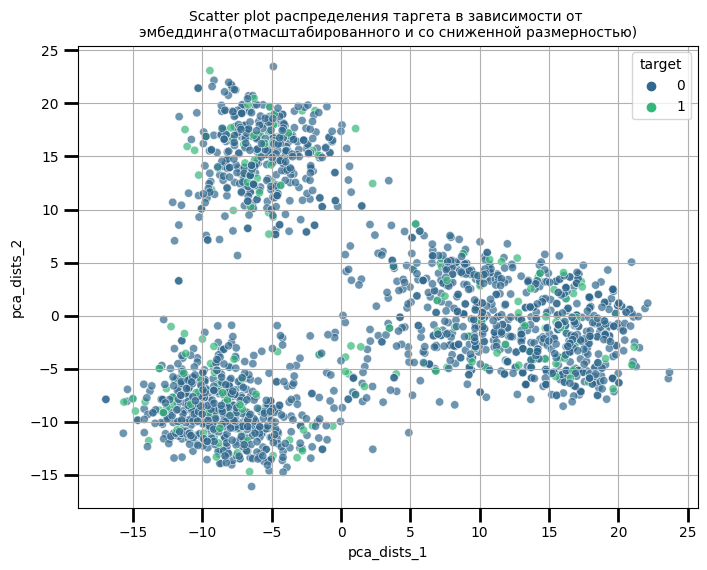

In [16]:
# Строим scatter plot с hue=Target
plt.figure(figsize=(8, 6))
sns.scatterplot(data=embs_pca[:2000], x='pca_dists_1', y="pca_dists_2", hue='target', palette='viridis', alpha=0.7)
plt.title('Scatter plot распределения таргета в зависимости от \n\
эмбеддинга(отмасштабированного и со сниженной размерностью)')
plt.grid(True)
plt.show()

###  Model 5. (user features - low importance) + (distillbert embeddings)

In [33]:
all_df_plus_bert = all_df_reduced.merge(embs_df,left_on="post_id", right_on="post_id")

In [46]:
leak_fs=['target','user_id', 'post_id', 'timestamp','text','action']
disbalanced_fs=['city','country']
low_importance_fs = ['os','dow','source']

X=all_df_plus_bert.drop(leak_fs + disbalanced_fs + low_importance_fs, axis=1)
y=all_df_plus_bert['target']

cat_feats = ['text_cluster', 'gender', 'country','city','exp_group','os','source','dow', 'topic']
cat_feats = [item for item in cat_feats if item in X.columns]

catboost_model = make_catboost_model(cat_feats)

model_tests4 = ModelContest(X=X,
                           y=y,
                           model=catboost_model,
                           model_description='*good user feats* and bert generated embeddings',
                           checkpoint_df=model_tests3.get_results_df()
                           )

model_tests4.evaluate()

,model_name,model_description,train_f1,test_f1,train_roc_auc,test_roc_auc,time_spent
0,DummyClassifier,baseline,0.000,0.000,0.500,0.500,0.67 seconds
1,CatBoostClassifier,all user features,0.273,0.247,0.661,0.605,28.50 seconds
2,CatBoostClassifier,removed low importance and disbalanced features,0.253,0.235,0.624,0.590,19.17 seconds
3,CatBoostClassifier,*good user feats* and tf_idf based feats,0.269,0.249,0.652,0.614,56.85 seconds
4,CatBoostClassifier,*good user feats* and bert generated embeddings,0.270,0.248,0.654,0.612,331.85 seconds


# 'topic' + 'likes' + 'views' - Прогнозирование на основе комбинации признаков из таблиц posts и feed 

## 3.5 likes/views ratio, likes/views ratio by topic

#### Здесь будет проведена оценка призна сгенерированного признака - отношения лайков к просмотрам для каждого пользователя

In [4]:
likes_ratio = all_df \
    .groupby('user_id', as_index=False) \
    .agg({'timestamp':'count', 'target':'sum'}) \
    .rename(columns={'timestamp':'views', 'target':'likes'})

likes_ratio['likes/views'] = likes_ratio.likes / likes_ratio.views

likes_ratio

,user_id,views,likes,likes/views
0,1728,282,15,0.053191
1,1729,561,72,0.128342
2,1730,480,47,0.097917
3,1731,752,139,0.184840
4,1732,354,25,0.070621
...,...,...,...,...
7183,162719,246,7,0.028455
7184,162720,543,44,0.081031
7185,162721,385,52,0.135065
7186,162722,214,36,0.168224


In [5]:
likes_ratio.isna().sum()

user_id        0
views          0
likes          0
likes/views    0
dtype: int64

In [18]:
# агрегация по user_id и topic, подсчёт активности и количество лайков
likes_ratio_by_topic = all_df \
    .groupby(['user_id','topic'], as_index=False) \
    .agg({'timestamp':'count', 'target':'sum'}) \
    .rename(columns={'timestamp':'views', 'target':'likes'})

likes_ratio_by_topic['likes/views'] = round( (likes_ratio_by_topic.likes / likes_ratio_by_topic.views), 5)

# Создание сводной таблицы, 
#разворачивание столбца topic в несколько столбцов, для удобства работы модели 

likes_ratio_by_topic = likes_ratio_by_topic \
    .pivot(columns='topic', index='user_id', values='likes/views') \
    .reset_index() \
    .rename_axis(None, axis=1)

# переименование столбцов
likes_ratio_by_topic.columns = ['user_id'] + ['likes/views ' + str(col) for col in likes_ratio_by_topic.columns[1:]]


likes_ratio_by_topic

,user_id,likes/views business,likes/views covid,likes/views entertainment,likes/views movie,likes/views politics,likes/views sport,likes/views tech
0,1728,0.15385,0.07792,0.11111,0.01980,0.00000,0.03030,0.00000
1,1729,0.05263,0.17742,0.08333,0.23881,0.04808,0.06731,0.06061
2,1730,0.06250,0.12727,0.03030,0.08939,0.16129,0.07407,0.00000
3,1731,0.23377,0.12791,0.18750,0.18493,0.22414,0.25000,0.14286
4,1732,0.11111,0.05556,0.12500,0.05882,0.08108,0.11429,0.07143
...,...,...,...,...,...,...,...,...
7183,162719,0.05263,0.02128,0.00000,0.02222,0.00000,0.05714,0.05556
7184,162720,0.08571,0.09483,0.08696,0.09929,0.03333,0.06667,0.12121
7185,162721,0.26667,0.11364,0.22222,0.18421,0.06667,0.05455,0.00000
7186,162722,0.14286,0.18966,0.33333,0.21333,0.05882,0.08333,0.00000


In [14]:
likes_ratio_by_topic.isna().sum()

user_id                      0
likes/views business         4
likes/views covid            0
likes/views entertainment    5
likes/views movie            2
likes/views politics         2
likes/views sport            2
likes/views tech             2
dtype: int64

In [15]:
likes_ratio_by_topic.fillna(0,inplace=True)
likes_ratio_by_topic.isna().sum()

user_id                      0
likes/views business         0
likes/views covid            0
likes/views entertainment    0
likes/views movie            0
likes/views politics         0
likes/views sport            0
likes/views tech             0
dtype: int64

In [21]:
likes_ratio_by_topic = likes_ratio.drop('likes',axis=1)\
        .merge(likes_ratio_by_topic, how='inner', on='user_id')

likes_ratio_by_topic

,user_id,views,likes/views,likes/views business,likes/views covid,likes/views entertainment,likes/views movie,likes/views politics,likes/views sport,likes/views tech
0,1728,282,0.053191,0.15385,0.07792,0.11111,0.01980,0.00000,0.03030,0.00000
1,1729,561,0.128342,0.05263,0.17742,0.08333,0.23881,0.04808,0.06731,0.06061
2,1730,480,0.097917,0.06250,0.12727,0.03030,0.08939,0.16129,0.07407,0.00000
3,1731,752,0.184840,0.23377,0.12791,0.18750,0.18493,0.22414,0.25000,0.14286
4,1732,354,0.070621,0.11111,0.05556,0.12500,0.05882,0.08108,0.11429,0.07143
...,...,...,...,...,...,...,...,...,...,...
7183,162719,246,0.028455,0.05263,0.02128,0.00000,0.02222,0.00000,0.05714,0.05556
7184,162720,543,0.081031,0.08571,0.09483,0.08696,0.09929,0.03333,0.06667,0.12121
7185,162721,385,0.135065,0.26667,0.11364,0.22222,0.18421,0.06667,0.05455,0.00000
7186,162722,214,0.168224,0.14286,0.18966,0.33333,0.21333,0.05882,0.08333,0.00000


In [6]:
all_df_reduced

,user_id,gender,age,country,city,exp_group,os,source,timestamp,dow,post_id,action,target,text,topic
0,162723,1,22,Russia,Svetlogorsk,1,Android,organic,2021-10-05 14:23:10,1,3952,view,0,Read this article about training and safety of...,covid
1,162723,1,22,Russia,Svetlogorsk,1,Android,organic,2021-10-05 14:23:39,1,2530,view,1,"Syed Bokhari, 57yo HCW, Woodhull Hosp, NY, die...",covid
2,162722,0,54,Kazakhstan,Zyryanovsk,2,Android,organic,2021-10-04 12:29:28,0,6276,view,1,"Nifty little episode played mainly for laughs,...",movie
3,162722,0,54,Kazakhstan,Zyryanovsk,2,Android,organic,2021-10-04 12:30:12,0,6823,view,0,Northanger Abbey is not my favorite Jane Auste...,movie
4,162722,0,54,Kazakhstan,Zyryanovsk,2,Android,organic,2021-10-04 12:32:30,0,3495,view,1,German news Frankfurter Rundschau reporting Ge...,covid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:36:34,2,5269,view,0,This is without question one of the worst movi...,movie
299996,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:38:35,2,6631,view,0,"One of the unsung gems of the 1980s, Scenes......",movie
299997,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:40:59,2,3480,view,0,Hey guys am in search of Nembutal pills or the...,covid
299998,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:41:48,2,3027,view,0,@hackneycouncil So your repair team told my ch...,covid


### Model 6. (user_features - low_importance_features) + like/views_by_topic

In [11]:
(likes_ratio_by_topic['user_id'].nunique(),all_df_reduced['user_id'].nunique())

(7188, 709)

In [15]:
all_df_4_model = all_df_reduced\
    .merge(likes_ratio_by_topic, how='inner',on='user_id')

all_df_4_model

,user_id,gender,age,country,city,exp_group,os,source,timestamp,dow,...,topic,views,likes/views,likes/views business,likes/views covid,likes/views entertainment,likes/views movie,likes/views politics,likes/views sport,likes/views tech
0,162723,1,22,Russia,Svetlogorsk,1,Android,organic,2021-10-05 14:23:10,1,...,covid,2,0.500000,0.00000,0.50000,0.00000,0.00000,0.00000,0.00000,0.00000
1,162723,1,22,Russia,Svetlogorsk,1,Android,organic,2021-10-05 14:23:39,1,...,covid,2,0.500000,0.00000,0.50000,0.00000,0.00000,0.00000,0.00000,0.00000
2,162722,0,54,Kazakhstan,Zyryanovsk,2,Android,organic,2021-10-04 12:29:28,0,...,movie,214,0.168224,0.14286,0.18966,0.33333,0.21333,0.05882,0.08333,0.00000
3,162722,0,54,Kazakhstan,Zyryanovsk,2,Android,organic,2021-10-04 12:30:12,0,...,movie,214,0.168224,0.14286,0.18966,0.33333,0.21333,0.05882,0.08333,0.00000
4,162722,0,54,Kazakhstan,Zyryanovsk,2,Android,organic,2021-10-04 12:32:30,0,...,covid,214,0.168224,0.14286,0.18966,0.33333,0.21333,0.05882,0.08333,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:36:34,2,...,movie,605,0.089256,0.06250,0.09091,0.08333,0.12340,0.09524,0.01408,0.02778
299996,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:38:35,2,...,movie,605,0.089256,0.06250,0.09091,0.08333,0.12340,0.09524,0.01408,0.02778
299997,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:40:59,2,...,covid,605,0.089256,0.06250,0.09091,0.08333,0.12340,0.09524,0.01408,0.02778
299998,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:41:48,2,...,covid,605,0.089256,0.06250,0.09091,0.08333,0.12340,0.09524,0.01408,0.02778


In [25]:
leak_fs=['target','user_id', 'post_id', 'timestamp','text','action']
disbalanced_fs=['city','country']
low_importance_fs = ['os','dow','source']


X=all_df_4_model.drop(leak_fs + low_importance_fs, axis=1)
y=all_df_4_model['target']

cat_feats = ['gender', 'country','city','exp_group','os','source','dow', 'topic']
cat_feats = [item for item in cat_feats if item in X.columns]

catboost_model = make_catboost_model(cat_feats)

model_tests6 = ModelContest(X=X,
                           y=y,
                           model=catboost_model,
                           model_description="user features + likes/views ratio",
                           checkpoint_df=checkpoint_df
                           )

model_tests6.evaluate()

,model_name,model_description,train_f1,test_f1,test_f1 variance x100,train_roc_auc,test_roc_auc,time_spent,test_f1_variance
0,DummyClassifier,baseline,0.000,0.000,0.0000,0.500,0.500,0.70 seconds,NaN
1,CatBoostClassifier,all user features,0.273,0.247,0.6650,0.661,0.605,30.87 seconds,NaN
2,CatBoostClassifier,removed low importance,0.273,0.245,0.5369,0.661,0.603,26.59 seconds,NaN
3,CatBoostClassifier,minus low importance and added tf_idf based feats,0.286,0.253,0.4835,0.683,0.617,68.39 seconds,NaN
4,CatBoostClassifier,minus low importance + scaled bert embeddings,0.286,0.266,NaN,0.684,0.642,32.51 seconds,0.0


# "post_id" + "likes" + "views" - прогнозирование вероятности лайка на основе отношения уже имеющихся просмотров и лайков

In [74]:
likes_views_by_post_id =  pd.read_sql(
    """SELECT post_id, 
                COUNT(timestamp) AS post_views,
                SUM(target) AS post_likes
    FROM feed_data
    GROUP BY post_id
    """,
    conn_uri
)

likes_views_by_post_id

,post_id,post_views,post_likes
0,1,9575,1067
1,2,8132,637
2,3,9534,1122
3,4,9329,1171
4,5,9736,1153
...,...,...,...
6826,7315,19559,2619
6827,7316,7249,677
6828,7317,7534,731
6829,7318,7465,680


## 3.6 Окончательный вариант модели

### Model 7: user_features + like_ratio_by_topic + tf_idf + likes_views_by_post_id

In [76]:
all_df_4_model = all_df_4_model\
        .merge(posts_tf_idf.drop(['text','topic'],axis=1),left_on="post_id", right_on="post_id")\
        .merge(likes_views_by_post_id, left_on = 'post_id', right_on='post_id')

all_df_4_model

,user_id,gender,age,country,city,exp_group,os,source,timestamp,dow,...,pca-12,pca-13,pca-14,pca-15,pca-16,pca-17,pca-18,pca-19,post_views,post_likes
0,162723,1,22,Russia,Svetlogorsk,1,Android,organic,2021-10-05 14:23:10,1,...,0.008504,0.015179,0.001898,-0.013224,-0.009718,0.019501,0.015687,-0.003504,22961,2318
1,162723,1,22,Russia,Svetlogorsk,1,Android,organic,2021-10-05 14:23:39,1,...,-0.001713,0.001052,-0.008113,-0.000721,0.001040,0.004730,0.006964,0.006302,25012,2726
2,162722,0,54,Kazakhstan,Zyryanovsk,2,Android,organic,2021-10-04 12:29:28,0,...,-0.020624,-0.017628,0.013655,0.016544,-0.005596,0.002836,0.014491,0.017953,7423,685
3,162722,0,54,Kazakhstan,Zyryanovsk,2,Android,organic,2021-10-04 12:30:12,0,...,-0.010435,0.012844,0.011828,-0.008924,-0.025558,0.017905,0.036258,0.014966,7362,685
4,162722,0,54,Kazakhstan,Zyryanovsk,2,Android,organic,2021-10-04 12:32:30,0,...,-0.001477,0.009772,-0.002214,-0.004381,-0.011496,0.006435,0.009612,0.007148,9740,1152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:36:34,2,...,0.021375,-0.037548,-0.009166,-0.024677,0.042368,0.005386,0.030019,-0.013191,7438,730
299996,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:38:35,2,...,-0.018495,-0.005426,-0.001800,0.012620,-0.008712,-0.008872,0.013492,0.014173,7543,754
299997,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:40:59,2,...,-0.028421,-0.025959,0.017315,-0.008459,0.026973,-0.017389,-0.014466,-0.021110,8010,697
299998,149142,1,49,Russia,Saransk,2,Android,organic,2021-12-15 10:41:48,2,...,0.003091,-0.007889,-0.028655,-0.024130,0.028924,-0.024758,-0.014057,-0.006320,8256,646


In [77]:
all_df_4_model.columns

Index(['user_id', 'gender', 'age', 'country', 'city', 'exp_group', 'os',
       'source', 'timestamp', 'dow', 'post_id', 'action', 'target', 'text',
       'topic', 'views', 'likes/views', 'likes/views business',
       'likes/views covid', 'likes/views entertainment', 'likes/views movie',
       'likes/views politics', 'likes/views sport', 'likes/views tech',
       'text_cluster', 'pca_dists_1', 'pca_dists_2', 'DistanceTo1thCluster',
       'DistanceTo2thCluster', 'DistanceTo3thCluster', 'DistanceTo4thCluster',
       'DistanceTo5thCluster', 'DistanceTo6thCluster', 'DistanceTo7thCluster',
       'DistanceTo8thCluster', 'DistanceTo9thCluster', 'DistanceTo10thCluster',
       'pca-0', 'pca-1', 'pca-2', 'pca-3', 'pca-4', 'pca-5', 'pca-6', 'pca-7',
       'pca-8', 'pca-9', 'pca-10', 'pca-11', 'pca-12', 'pca-13', 'pca-14',
       'pca-15', 'pca-16', 'pca-17', 'pca-18', 'pca-19', 'post_views',
       'post_likes'],
      dtype='object')

In [78]:
leak_fs=['target','user_id', 'post_id', 'timestamp','text','action']
disbalanced_fs=['city','country']
low_importance_fs = ['os','dow','source']


X = all_df_4_model.drop(leak_fs + low_importance_fs, axis=1)
y = all_df_4_model['target']

cat_feats = ['text_cluster','gender', 'country','city','exp_group','os',\
             'source','dow', 'topic']

cat_feats = [item for item in cat_feats if item in X.columns]

catboost_model = make_catboost_model(cat_feats)

model_tests7 = ModelContest(X=X,
                           y=y,
                           model=catboost_model,
                           model_description="user features + likes/views ratio + tf_idf",
                           checkpoint_df=model_tests6.get_results_df()
                           )

model_tests7.evaluate()

,model_name,model_description,train_f1,test_f1,test_f1 variance x100,train_roc_auc,test_roc_auc,time_spent,test_f1_variance
0,DummyClassifier,baseline,0.000,0.000,0.0000,0.500,0.500,0.70 seconds,NaN
1,CatBoostClassifier,all user features,0.273,0.247,0.6650,0.661,0.605,30.87 seconds,NaN
2,CatBoostClassifier,removed low importance,0.273,0.245,0.5369,0.661,0.603,26.59 seconds,NaN
3,CatBoostClassifier,minus low importance and added tf_idf based feats,0.286,0.253,0.4835,0.683,0.617,68.39 seconds,NaN
4,CatBoostClassifier,minus low importance + scaled bert embeddings,0.286,0.266,NaN,0.684,0.642,32.51 seconds,0.0
5,CatBoostClassifier,user features + likes/views ratio + tf_idf,0.315,0.294,NaN,0.733,0.689,79.64 seconds,0.0
